In [2]:
# import required classes
import pandas as pd
import glob
import re
from pathlib import Path
import numpy as np        
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from tabulate import tabulate
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_validate, cross_val_score, train_test_split, KFold, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score, precision_score, recall_score, make_scorer, f1_score, precision_recall_curve, average_precision_score, roc_auc_score, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer   
from sklearn.pipeline import Pipeline 
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Classifiers
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from xgboost import XGBClassifier

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


In [3]:
#import data files
df_original = pd.read_csv('data/sstaudent_data.csv', sep=',')

# Since data has been previously encoded, load in dictionaries
dictionary = {}
for f in glob.glob("data/dictionaries/*.csv"):
    cat_df = pd.read_csv(f)
    cat_df["combined"] =  cat_df["label"] #cat_df["value"].astype(str) + ": " +
    dictionary[Path(f).stem] = dict(zip(cat_df["value"], cat_df["combined"]))


## 1. EDA
### 1.0 Data prep

In [4]:
# standardize column names by lowercasing, removing spacial chars, and 
df = df_original.copy()    
new_columns = []

for col in df.columns:
    temp_col = str(col).lower()
    temp_col = temp_col.replace(' ', '_')
    temp_col = re.sub(r'[^a-z0-9_]', '', temp_col)
    new_columns.append(temp_col)
    
df.columns = new_columns

In [5]:
# create new columns with the translated categorical defintions
decoded_df = df.copy()
decoded_df['marital_status_decoded'] = df['marital_status'].map(dictionary['tA1_marital_status']).astype('category')
decoded_df['application_mode_decoded'] = df['application_mode'].map(dictionary['tA3_application_mode']).astype('category')
decoded_df['course_decoded'] = df['course'].map(dictionary['tA4_course_names']).astype('category')
decoded_df['daytimeevening_attendance_decoded'] = df['daytimeevening_attendance'].map(dictionary['tA9_attendance_regime']).astype('category')
decoded_df['previous_qualification_decoded'] = df['previous_qualification'].map(dictionary['tA5_previous_quals']).astype('category')
decoded_df['nationality_decoded'] = df['application_mode'].map(dictionary['tA2_nationality']).astype('category')
decoded_df['mothers_qualification_decoded'] = df['mothers_qualification'].map(dictionary['tA6_parent_previous_quals']).astype('category')
decoded_df['fathers_qualification_decoded'] = df['fathers_qualification'].map(dictionary['tA6_parent_previous_quals']).astype('category')
decoded_df['mothers_occupation_decoded'] = df['mothers_occupation'].map(dictionary['tA7_parent_occupation']).astype('category')
decoded_df['fathers_occupation_decoded'] = df['fathers_occupation'].map(dictionary['tA7_parent_occupation']).astype('category')
decoded_df['gender_decoded'] = df['gender'].map(dictionary['tA8_gender']).astype('category')
decoded_df['displaced_decoded'] = df['displaced'].map(dictionary['tA10_yes_no']).astype('category')
decoded_df['educational_special_needs_decoded'] = df['educational_special_needs'].map(dictionary['tA10_yes_no']).astype('category')
decoded_df['tuition_fees_up_to_date_decoded'] = df['tuition_fees_up_to_date'].map(dictionary['tA10_yes_no']).astype('category')
decoded_df['debtor_decoded'] = df['debtor'].map(dictionary['tA10_yes_no']).astype('category')
decoded_df['scholarship_holder_decoded'] = df['scholarship_holder'].map(dictionary['tA10_yes_no']).astype('category')
decoded_df['international_decoded'] = df['international'].map(dictionary['tA10_yes_no']).astype('category')



In [6]:
# Define numerical variables
noncategorical_cols = ['age_at_enrollment', 'application_order',
'curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled',
'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved',
'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations',
'curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled',
'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved',
'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations',
'unemployment_rate', 'inflation_rate', 'gdp']

# Make lists for  categorical columns
categorical_cols_orginal = ['marital_status', 'application_mode', 'course',
       'daytimeevening_attendance', 'previous_qualification', 'nationality',
       'mothers_qualification', 'fathers_qualification', 'mothers_occupation',
       'fathers_occupation', 'displaced', 'educational_special_needs',
       'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder',
       'international']

# Make lists for  categorical columns with decoded values
categorical_cols_decoded = ['marital_status_decoded', 'application_mode_decoded', 'course_decoded',
       'daytimeevening_attendance_decoded', 'previous_qualification_decoded', 'nationality_decoded',
       'mothers_qualification_decoded', 'fathers_qualification_decoded', 'mothers_occupation_decoded',
       'fathers_occupation_decoded', 'displaced_decoded', 'educational_special_needs_decoded',
       'debtor_decoded', 'tuition_fees_up_to_date_decoded', 'gender_decoded', 
       'scholarship_holder_decoded', 'international_decoded']

# convert col type to categorical
for i, col in enumerate(categorical_cols_orginal):
   df[col] = df[col].astype('category')
   decoded_df[col] = decoded_df[col].astype('category')


### 1.1 Shape of DataFrame

In [7]:

print(decoded_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 52 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   marital_status                                4424 non-null   category
 1   application_mode                              4424 non-null   category
 2   application_order                             4424 non-null   int64   
 3   course                                        4424 non-null   category
 4   daytimeevening_attendance                     4424 non-null   category
 5   previous_qualification                        4424 non-null   category
 6   nationality                                   4424 non-null   category
 7   mothers_qualification                         4424 non-null   category
 8   fathers_qualification                         4424 non-null   category
 9   mothers_occupation                            4424 n

### 1.2 Missing Values

In [8]:
#check null rows - inverse of non-null values
null_counts = decoded_df.isnull().sum()
null_counts = null_counts[null_counts > 0]
print(null_counts)

fathers_occupation_decoded    1
dtype: int64


### 1.3 Non-Categorical Variables

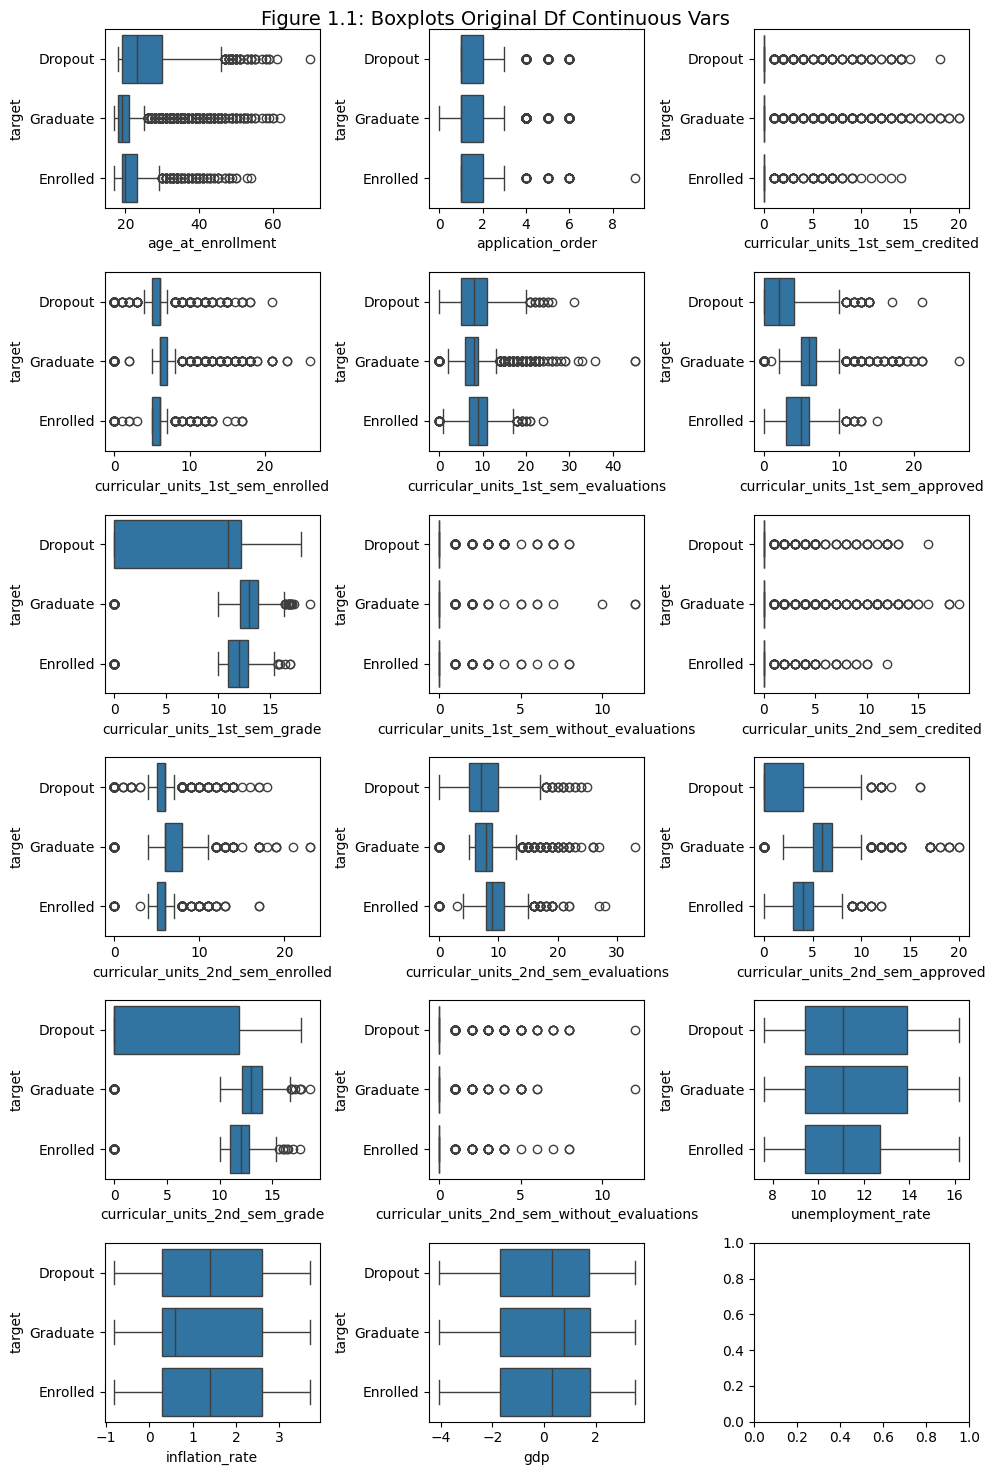

In [9]:
# Create Boxplots for Non-Categorical Values
fig, axes = plt.subplots(ncols=3, nrows=6, figsize=(10, 15))
x_counter = 0
y_counter = 0
for i, col in enumerate(noncategorical_cols):
    sns.boxplot(data=decoded_df, x=col, y='target', ax=axes[y_counter, x_counter])
    x_counter += 1
    if x_counter == 3:
        x_counter = 0
        y_counter += 1
    if i == len(noncategorical_cols) :
        break

fig.suptitle("Figure 1.1: Boxplots Original Df Continuous Vars", fontsize=14)
plt.tight_layout()
plt.show()


In [10]:
# summary of non-categorical variables
print('\nSummary metrics for numerical fields | Original Df')
print(decoded_df.describe())

for i, col in enumerate(noncategorical_cols):
        
    top_values = decoded_df.nlargest(5, col)
    
    print(f'\nTop 5 `{col}`', top_values[col])
    Q1 = decoded_df[col].quantile(0.25)
    Q3 = decoded_df[col].quantile(0.75)
    upper_whisker =  Q3 + 1.5 * (Q3 - Q1)
    
    print(f'\nUpper Whisker: `{col}`', upper_whisker)
    count_above_whisker = (decoded_df[col] > upper_whisker).sum()
    print("Count above upper whisker:", count_above_whisker)


Summary metrics for numerical fields | Original Df
       application_order  age_at_enrollment  \
count        4424.000000        4424.000000   
mean            1.727848          23.265145   
std             1.313793           7.587816   
min             0.000000          17.000000   
25%             1.000000          19.000000   
50%             1.000000          20.000000   
75%             2.000000          25.000000   
max             9.000000          70.000000   

       curricular_units_1st_sem_credited  curricular_units_1st_sem_enrolled  \
count                        4424.000000                        4424.000000   
mean                            0.709991                           6.270570   
std                             2.360507                           2.480178   
min                             0.000000                           0.000000   
25%                             0.000000                           5.000000   
50%                             0.000000          

### 1.4 - Categorical Variables
Since data has been previously encoded, we build a dictionary to translate the encoding to the categorical definitions


Categorical Values by Column:


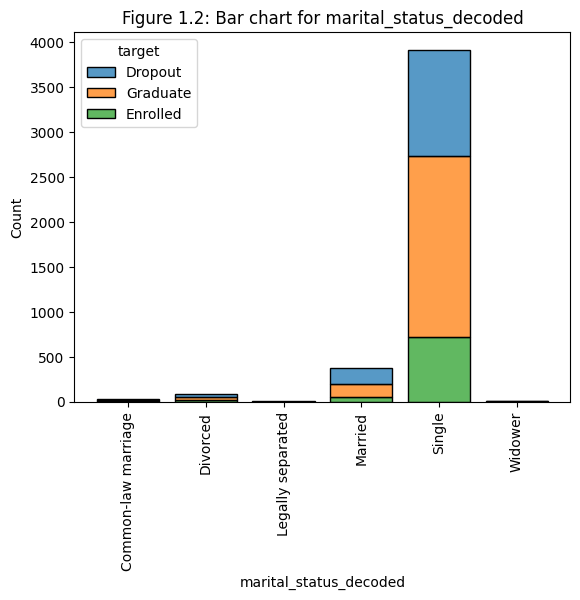


Values for DF column : marital_status_decoded
                        Count  Percentage
marital_status_decoded                   
Single                   3919       88.58
Married                   379        8.57
Divorced                   91        2.06
Common-law marriage        25        0.57
Legally separated           6        0.14
Widower                     4        0.09


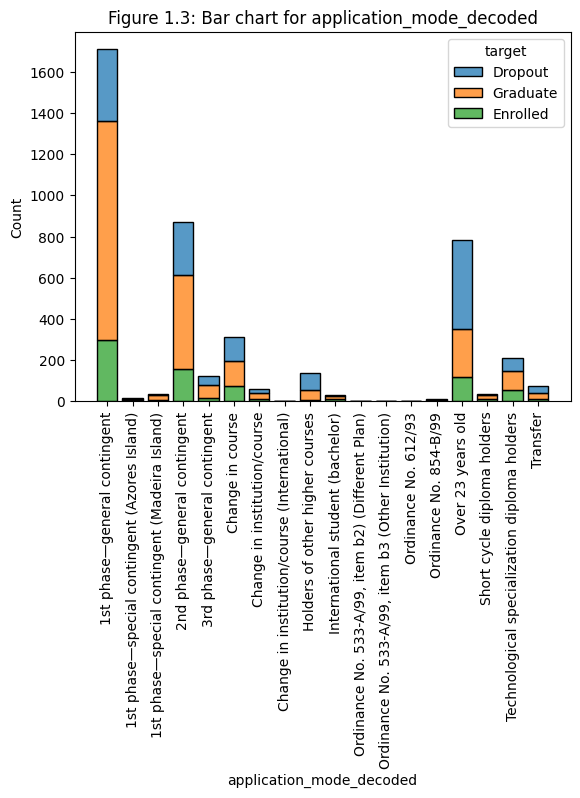


Values for DF column : application_mode_decoded
                                                    Count  Percentage
application_mode_decoded                                             
1st phase—general contingent                         1708       38.61
2nd phase—general contingent                          872       19.71
Over 23 years old                                     785       17.74
Change in course                                      312        7.05
Technological specialization diploma holders          213        4.81
Holders of other higher courses                       139        3.14
3rd phase—general contingent                          124        2.80
Transfer                                               77        1.74
Change in institution/course                           59        1.33
1st phase—special contingent (Madeira Island)          38        0.86
Short cycle diploma holders                            35        0.79
International student (bachelor)         

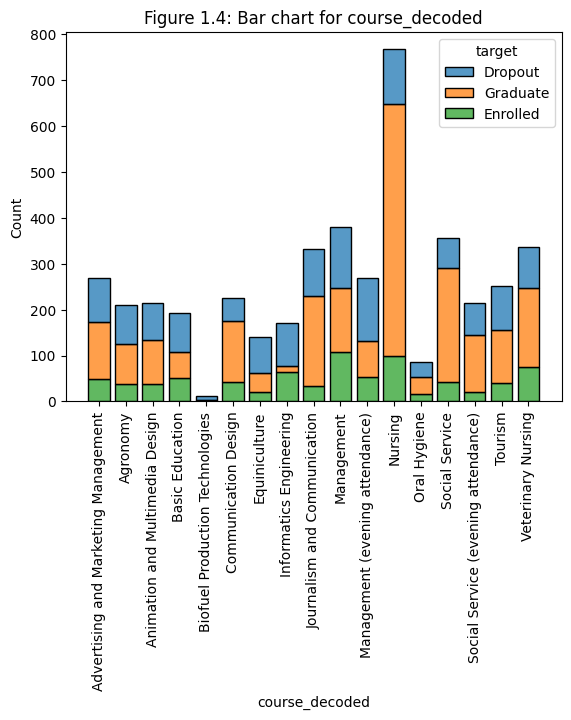


Values for DF column : course_decoded
                                      Count  Percentage
course_decoded                                         
Nursing                                 766       17.31
Management                              380        8.59
Social Service                          355        8.02
Veterinary Nursing                      337        7.62
Journalism and Communication            331        7.48
Management (evening attendance)         268        6.06
Advertising and Marketing Management    268        6.06
Tourism                                 252        5.70
Communication Design                    226        5.11
Animation and Multimedia Design         215        4.86
Social Service (evening attendance)     215        4.86
Agronomy                                210        4.75
Basic Education                         192        4.34
Informatics Engineering                 170        3.84
Equiniculture                           141        3.19
Oral Hygi

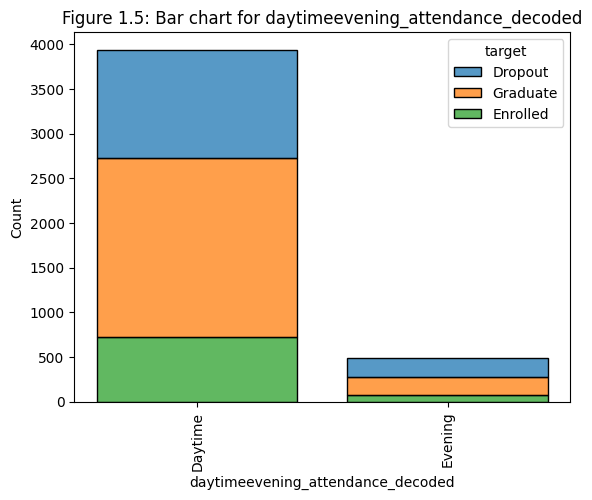


Values for DF column : daytimeevening_attendance_decoded
                                   Count  Percentage
daytimeevening_attendance_decoded                   
Daytime                             3941       89.08
Evening                              483       10.92


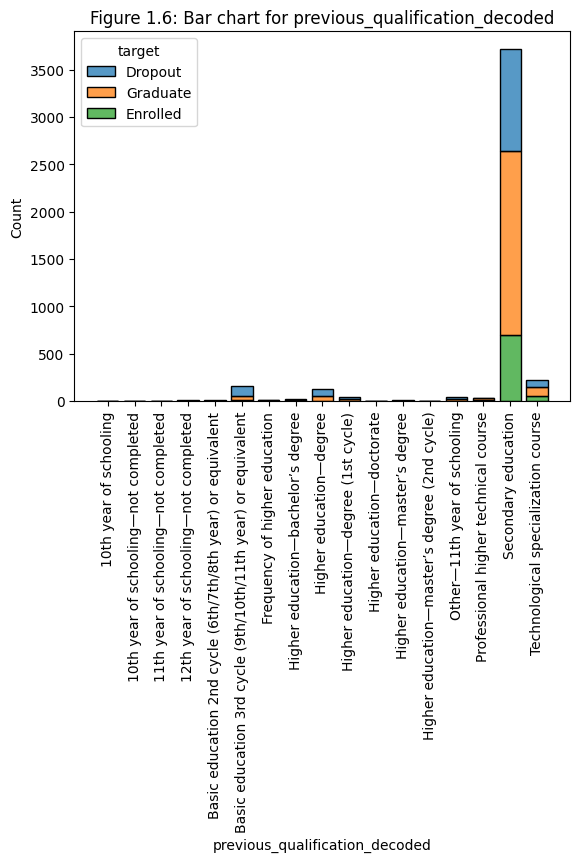


Values for DF column : previous_qualification_decoded
                                                    Count  Percentage
previous_qualification_decoded                                       
Secondary education                                  3717       84.02
Technological specialization course                   219        4.95
Basic education 3rd cycle (9th/10th/11th year) ...    162        3.66
Higher education—degree                               126        2.85
Other—11th year of schooling                           45        1.02
Higher education—degree (1st cycle)                    40        0.90
Professional higher technical course                   36        0.81
Higher education—bachelor’s degree                     23        0.52
Frequency of higher education                          16        0.36
12th year of schooling—not completed                   11        0.25
Higher education—master’s degree                        8        0.18
Basic education 2nd cycle (6th/7th/

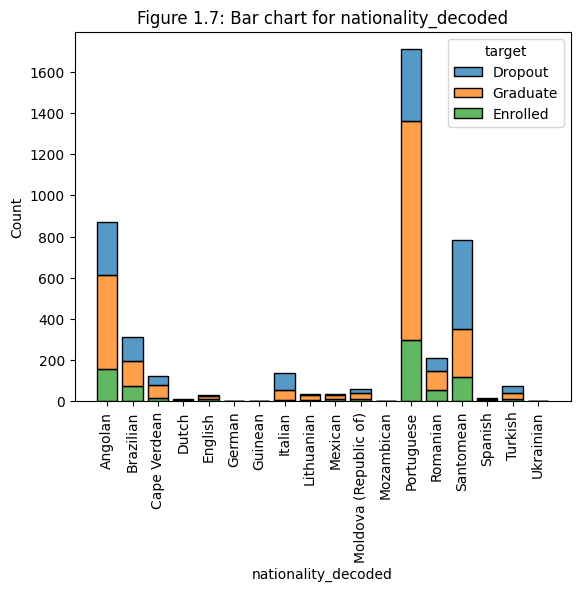


Values for DF column : nationality_decoded
                       Count  Percentage
nationality_decoded                     
Portuguese              1708       38.61
Angolan                  872       19.71
Santomean                785       17.74
Brazilian                312        7.05
Romanian                 213        4.81
Italian                  139        3.14
Cape Verdean             124        2.80
Turkish                   77        1.74
Moldova (Republic of)     59        1.33
Lithuanian                38        0.86
Mexican                   35        0.79
English                   30        0.68
Spanish                   16        0.36
Dutch                     10        0.23
German                     3        0.07
Mozambican                 1        0.02
Guinean                    1        0.02
Ukrainian                  1        0.02


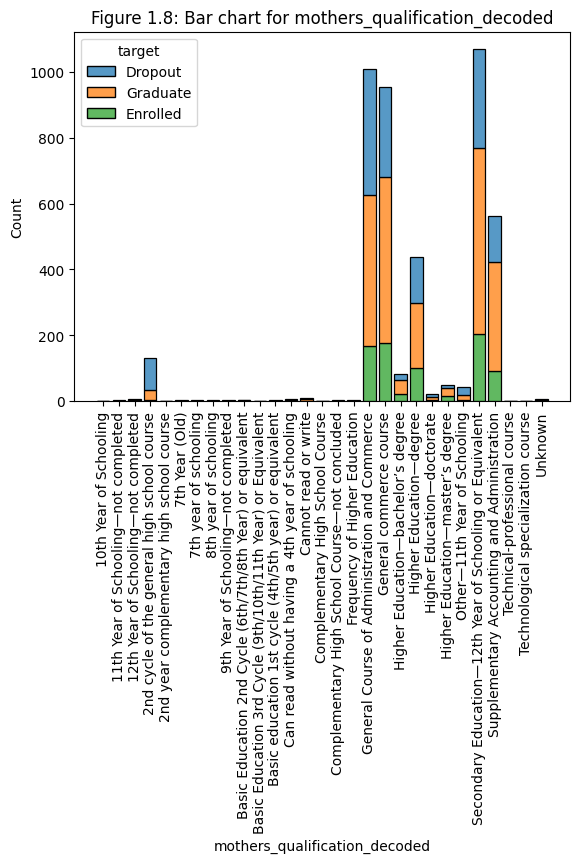


Values for DF column : mothers_qualification_decoded
                                                    Count  Percentage
mothers_qualification_decoded                                        
Secondary Education—12th Year of Schooling or E...   1069       24.16
General Course of Administration and Commerce        1009       22.81
General commerce course                               953       21.54
Supplementary Accounting and Administration           562       12.70
Higher Education—degree                               438        9.90
2nd cycle of the general high school course           130        2.94
Higher Education—bachelor’s degree                     83        1.88
Higher Education—master’s degree                       49        1.11
Other—11th Year of Schooling                           42        0.95
Higher Education—doctorate                             21        0.47
Cannot read or write                                    9        0.20
12th Year of Schooling—not completed

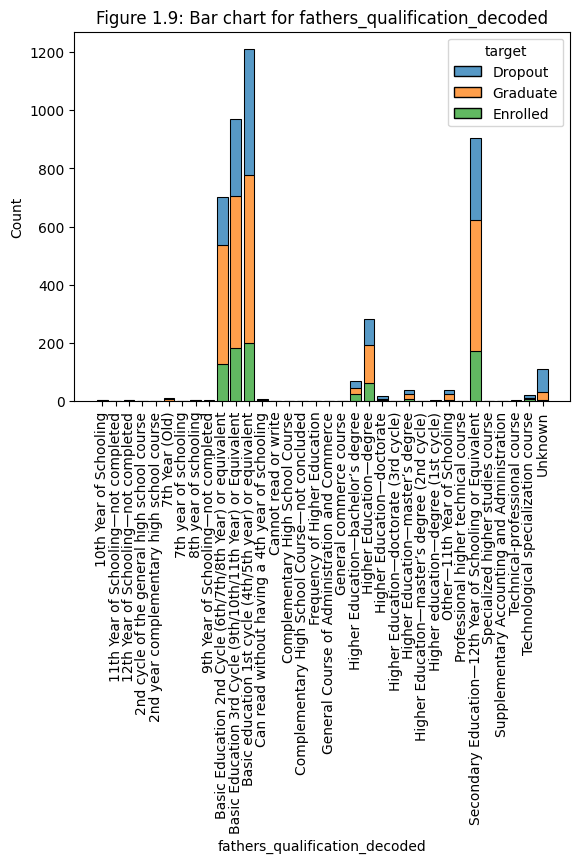


Values for DF column : fathers_qualification_decoded
                                                    Count  Percentage
fathers_qualification_decoded                                        
Basic education 1st cycle (4th/5th year) or equ...   1209       27.33
Basic Education 3rd Cycle (9th/10th/11th Year) ...    968       21.88
Secondary Education—12th Year of Schooling or E...    904       20.43
Basic Education 2nd Cycle (6th/7th/8th Year) or...    702       15.87
Higher Education—degree                               282        6.37
Unknown                                               112        2.53
Higher Education—bachelor’s degree                     68        1.54
Higher Education—master’s degree                       39        0.88
Other—11th Year of Schooling                           38        0.86
Technological specialization course                    20        0.45
Higher Education—doctorate                             18        0.41
7th Year (Old)                      

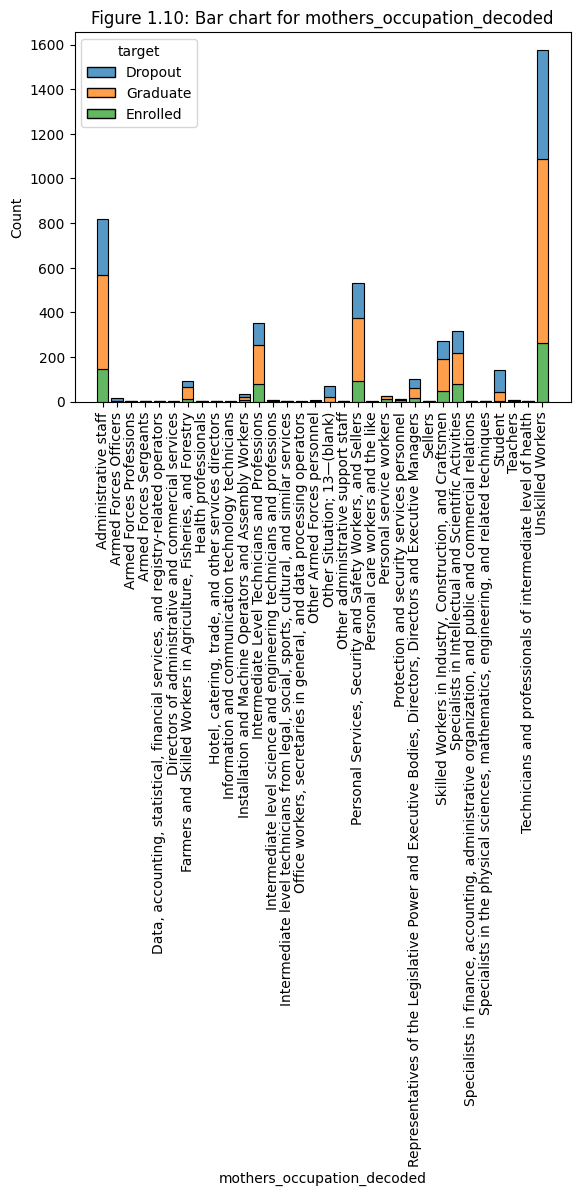


Values for DF column : mothers_occupation_decoded
                                                    Count  Percentage
mothers_occupation_decoded                                           
Unskilled Workers                                    1577       35.65
Administrative staff                                  817       18.47
Personal Services, Security and Safety Workers,...    530       11.98
Intermediate Level Technicians and Professions        351        7.93
Specialists in Intellectual and Scientific Acti...    318        7.19
Skilled Workers in Industry, Construction, and ...    272        6.15
Student                                               144        3.25
Representatives of the Legislative Power and Ex...    102        2.31
Farmers and Skilled Workers in Agriculture, Fis...     91        2.06
Other Situation; 13—(blank)                            70        1.58
Installation and Machine Operators and Assembly...     36        0.81
Personal service workers               

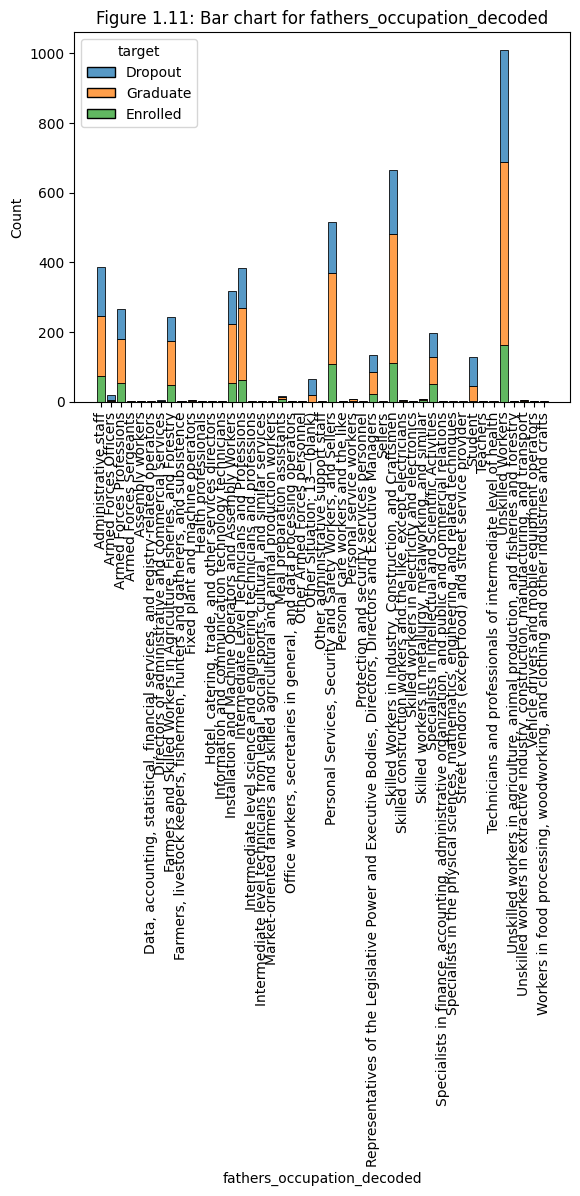


Values for DF column : fathers_occupation_decoded
                                                    Count  Percentage
fathers_occupation_decoded                                           
Unskilled Workers                                    1010       22.84
Skilled Workers in Industry, Construction, and ...    666       15.06
Personal Services, Security and Safety Workers,...    516       11.67
Administrative staff                                  386        8.73
Intermediate Level Technicians and Professions        384        8.68
Installation and Machine Operators and Assembly...    318        7.19
Armed Forces Professions                              266        6.01
Farmers and Skilled Workers in Agriculture, Fis...    242        5.47
Specialists in Intellectual and Scientific Acti...    197        4.45
Representatives of the Legislative Power and Ex...    134        3.03
Student                                               128        2.89
Other Situation; 13—(blank)            

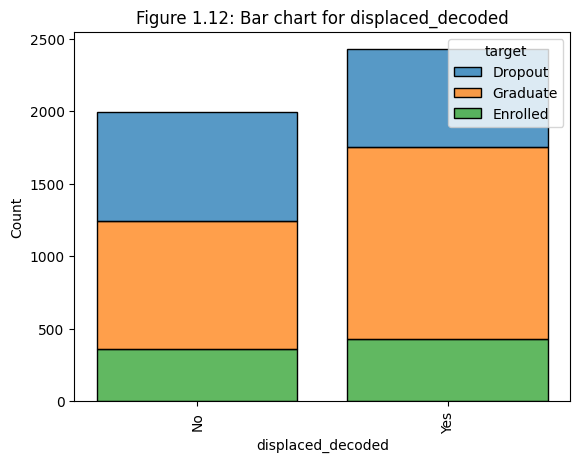


Values for DF column : displaced_decoded
                   Count  Percentage
displaced_decoded                   
Yes                 2426       54.84
No                  1998       45.16


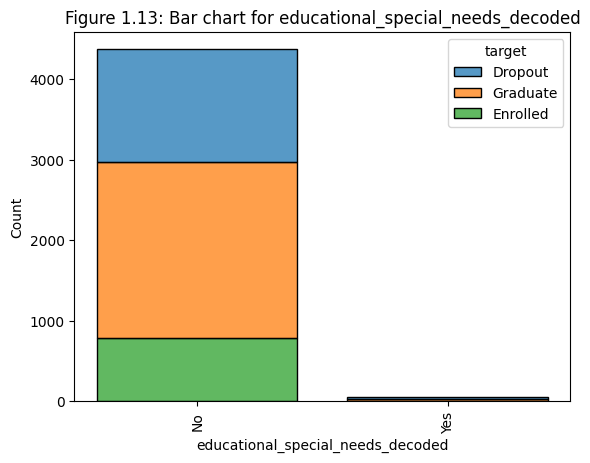


Values for DF column : educational_special_needs_decoded
                                   Count  Percentage
educational_special_needs_decoded                   
No                                  4373       98.85
Yes                                   51        1.15


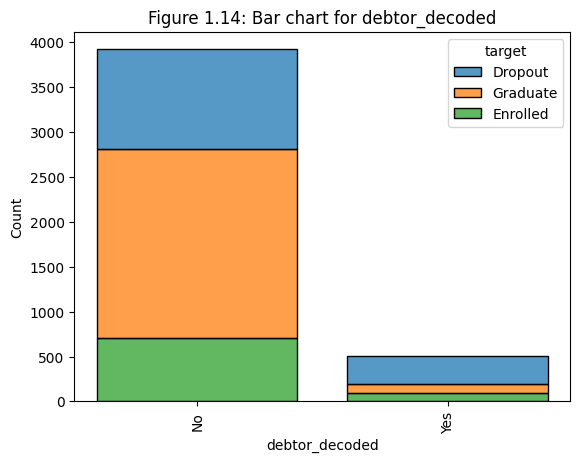


Values for DF column : debtor_decoded
                Count  Percentage
debtor_decoded                   
No               3921       88.63
Yes               503       11.37


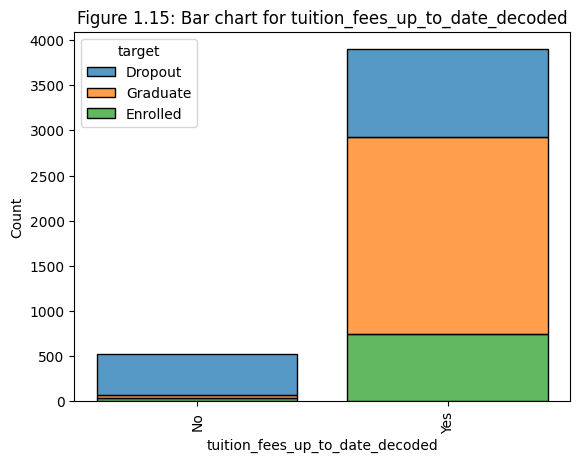


Values for DF column : tuition_fees_up_to_date_decoded
                                 Count  Percentage
tuition_fees_up_to_date_decoded                   
Yes                               3896       88.07
No                                 528       11.93


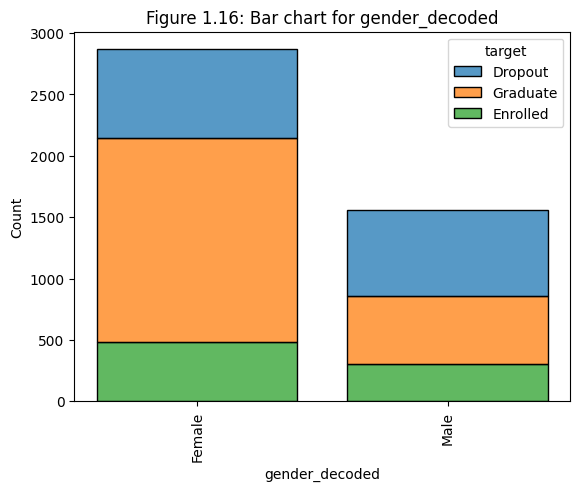


Values for DF column : gender_decoded
                Count  Percentage
gender_decoded                   
Female           2868       64.83
Male             1556       35.17


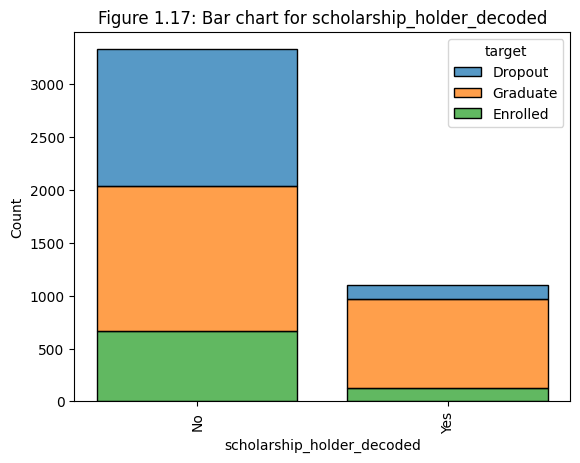


Values for DF column : scholarship_holder_decoded
                            Count  Percentage
scholarship_holder_decoded                   
No                           3325       75.16
Yes                          1099       24.84


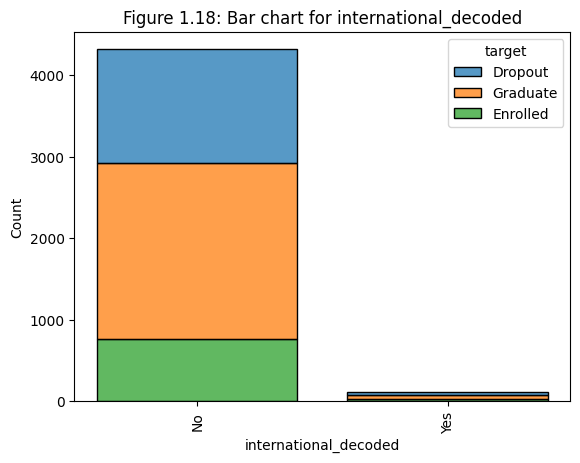


Values for DF column : international_decoded
                       Count  Percentage
international_decoded                   
No                      4314       97.51
Yes                      110        2.49


In [11]:
#  print value counts for each  column for our decoded categorical variables
       
print('\nCategorical Values by Column:')
for i, col in enumerate(categorical_cols_decoded):

    #decoded_df[col] = decoded_df[col].astype('category')
    order = decoded_df[col].value_counts().index
    decoded_df[col] = pd.Categorical(decoded_df[col], categories=order, ordered=True)


    sns.histplot(data=decoded_df, x=col, hue='target',  multiple="stack", shrink=0.8)
    plt.title(f'Figure 1.{i + 2}: Bar chart for {col}')
    plt.xticks(rotation=90)
    plt.show()

    decoded_df[col] = decoded_df[col].astype('category')
    val_counts = decoded_df[col].value_counts()
    val_percent = decoded_df[col].value_counts(normalize=True) * 100

    summary = pd.DataFrame({
        'Count': val_counts,
        'Percentage': val_percent.round(2) 
    })
    
    print(f"\nValues for DF column : {col}")
    print(summary)

#### 1.4.1 Possible Outliers
* One person age 70, where rest between 17-62. We can probably ignore or bin by age
* Possible data entry error in application_order. Only one "9", rest range from 1-6, with IQR between 1-2.


### 1.5 Check for Correlation


 Table 1: Pearson Correlation Coefficients
|                                                                                  |        0 |
|:---------------------------------------------------------------------------------|---------:|
| ('curricular_units_1st_sem_credited', 'curricular_units_2nd_sem_credited')       | 0.944811 |
| ('curricular_units_2nd_sem_credited', 'curricular_units_1st_sem_credited')       | 0.944811 |
| ('curricular_units_1st_sem_enrolled', 'curricular_units_2nd_sem_enrolled')       | 0.942627 |
| ('curricular_units_2nd_sem_enrolled', 'curricular_units_1st_sem_enrolled')       | 0.942627 |
| ('curricular_units_2nd_sem_approved', 'curricular_units_1st_sem_approved')       | 0.904002 |
| ('curricular_units_1st_sem_approved', 'curricular_units_2nd_sem_approved')       | 0.904002 |
| ('curricular_units_2nd_sem_grade', 'curricular_units_1st_sem_grade')             | 0.83717  |
| ('curricular_units_1st_sem_grade', 'curricular_units_2nd_sem_grade')             | 0.83717

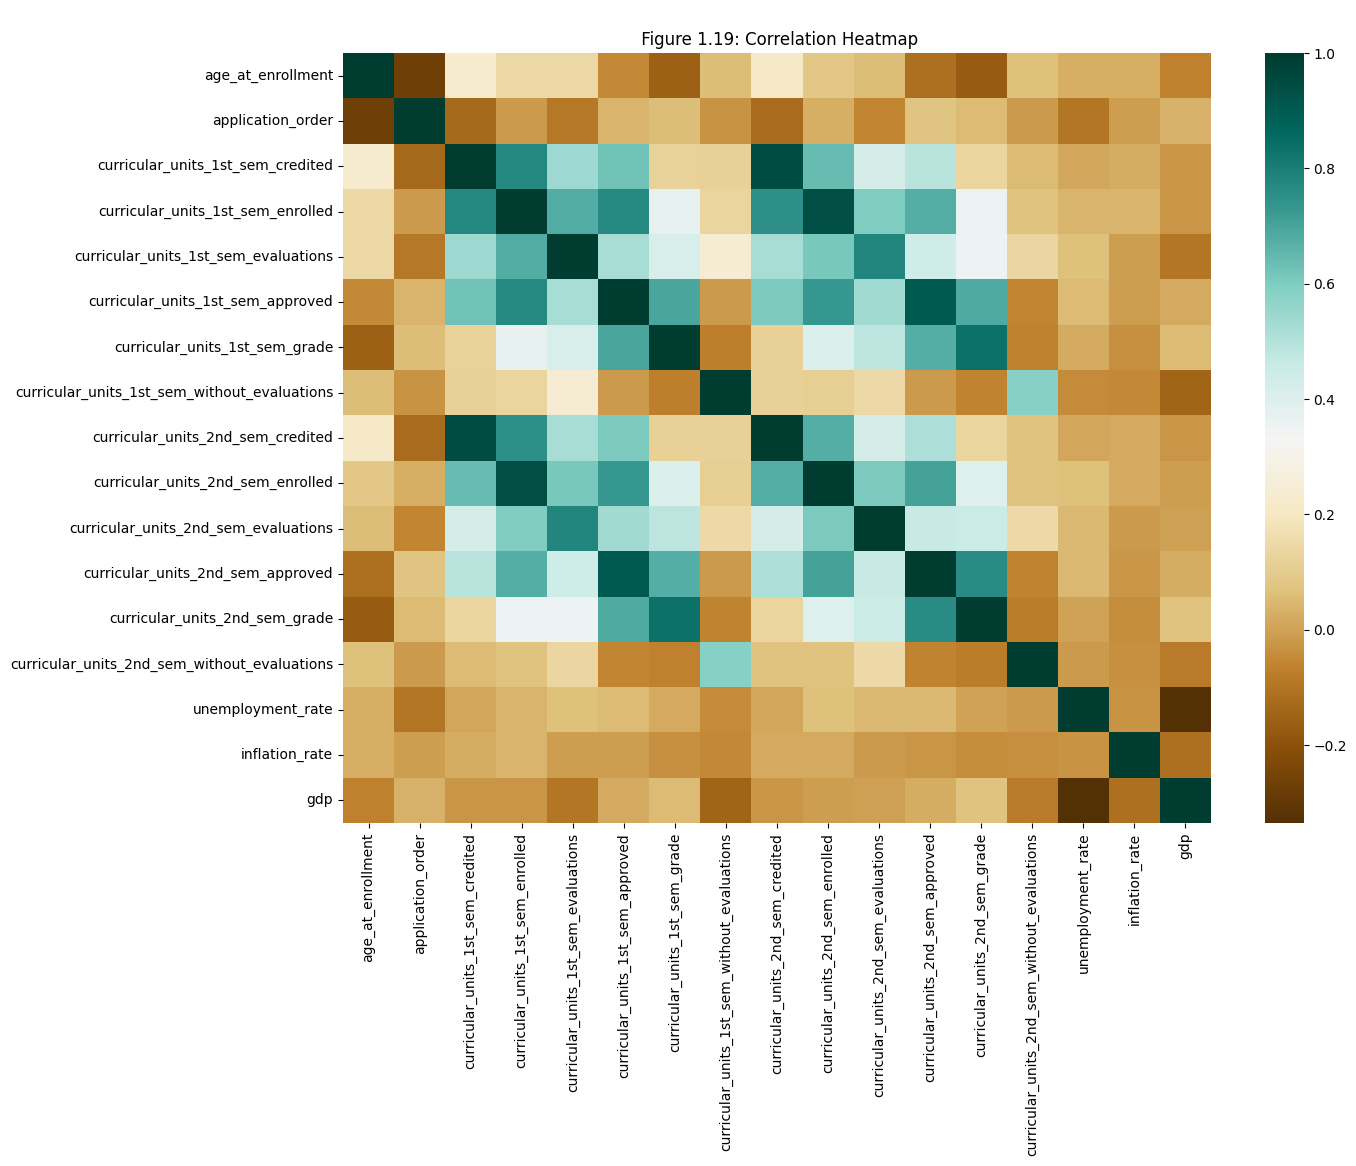

In [12]:
# Pearson Correlation Coefficitent Test
X = decoded_df[noncategorical_cols]

plt.figure(figsize=(14,10))
corr = X.corr()
sns.heatmap(corr, cmap="BrBG", annot=False)
plt.title('\n Figure 1.19: Correlation Heatmap')

print('\n Table 1: Pearson Correlation Coefficients')
# print values
corr_abs_sorted = corr.abs().unstack().sort_values(ascending=False)
corr_abs_sorted = corr_abs_sorted[corr_abs_sorted < 1]
print(corr_abs_sorted.head(20).to_markdown())

In [13]:
# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print('\n Table 2: VIF')
print(vif_data.to_markdown())


 Table 2: VIF
|    | feature                                      |       VIF |
|---:|:---------------------------------------------|----------:|
|  0 | curricular_units_1st_sem_enrolled            | 170.429   |
|  1 | curricular_units_2nd_sem_enrolled            | 149.019   |
|  2 | curricular_units_1st_sem_approved            |  41.5014  |
|  3 | curricular_units_2nd_sem_approved            |  31.9827  |
|  4 | curricular_units_1st_sem_grade               |  28.4883  |
|  5 | curricular_units_2nd_sem_grade               |  26.1611  |
|  6 | curricular_units_1st_sem_evaluations         |  19.4787  |
|  7 | curricular_units_2nd_sem_evaluations         |  17.2038  |
|  8 | curricular_units_1st_sem_credited            |  16.8436  |
|  9 | unemployment_rate                            |  13.8052  |
| 10 | curricular_units_2nd_sem_credited            |  13.396   |
| 11 | age_at_enrollment                            |   9.73529 |
| 12 | application_order                            |   2.797

### 1.6 Check for Imbalance 

Our data shows some imbalance. Ratio is closer if we do not count enrolled.

In [14]:
val_counts = decoded_df['target'].value_counts()
val_percent = decoded_df['target'].value_counts(normalize=True) * 100

print(pd.DataFrame({
    'Count': val_counts,
    'Percentage': val_percent.round(2) 
}))


print('Percent dropped out (if enrolled not counted):')
print(1338 / (1338 + 2129) * 100 )


          Count  Percentage
target                     
Graduate   2209       49.93
Dropout    1421       32.12
Enrolled    794       17.95
Percent dropped out (if enrolled not counted):
38.59244303432362


## 2. Feature Engineering

### 2.1.1 Impute missing values

The dataset had one missing value for `fathers_occupation_decoded`. A value was provided for `fathers_occupation` but doesn't match any in our dictionary so will convert to "Other". 

In [15]:
# Replace missing values with "Other"
decoded_df['fathers_occupation_decoded'] = decoded_df['fathers_occupation_decoded'].cat.add_categories(['Other'])
decoded_df['fathers_occupation_decoded'] = decoded_df['fathers_occupation_decoded'].fillna('Other')

#### 2.1.2 Drop rows for students without any academic information

180 of 4424 (~4%) observations have not values entered into any of the 12 1st and 2nd semester fields fields, but had different outcomes/targets. I will drop since this indicates that the student was not in school during the period of interest and records could just add noise to our models.

In [16]:
# drop rows that don't include any values in all of the following fields
curricular_unit_cols = ['curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled',
'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved',
'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations',
'curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled',
'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved',
'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations']

missing_vals_df = (decoded_df[curricular_unit_cols].eq(0).all(axis=1))
print(missing_vals_df.sum())

decoded_engineered_df =  decoded_df[~missing_vals_df].copy()

180


2.1.3 Combining fields

Create new engineered fields for total_credited, total_enrolled, total_evaluations, and total_approved with the sums of the respective values for te 1st and 2nd semester. Create weighted avg grade of both semesters' grades.

In [17]:
# combine 1st and 2nd semester variables
decoded_engineered_df["total_credited"] = decoded_engineered_df["curricular_units_1st_sem_credited"] + decoded_engineered_df["curricular_units_2nd_sem_credited"]
decoded_engineered_df["total_enrolled"] = decoded_engineered_df["curricular_units_1st_sem_enrolled"] + decoded_engineered_df["curricular_units_2nd_sem_enrolled"]
decoded_engineered_df["total_evaluations"] = decoded_engineered_df["curricular_units_1st_sem_evaluations"] + decoded_engineered_df["curricular_units_2nd_sem_evaluations"]
decoded_engineered_df["total_approved"] = decoded_engineered_df["curricular_units_1st_sem_approved"] + decoded_engineered_df["curricular_units_2nd_sem_approved"]

# omit total_wout_evaluations, since this information is captured in _enrolled and _evaluations
#decoded_engineered_df["total_wout_evaluations"] = decoded_engineered_df["curricular_units_1st_sem_without_evaluations"] + decoded_engineered_df["curricular_units_2nd_sem_without_evaluations"]

# create weighted grad average
g1 = decoded_engineered_df["curricular_units_1st_sem_grade"]
g2 = decoded_engineered_df["curricular_units_2nd_sem_grade"]
n1 = decoded_engineered_df["curricular_units_1st_sem_evaluations"]  
n2 = decoded_engineered_df["curricular_units_2nd_sem_evaluations"]
decoded_engineered_df["weighted_avg_grade"] = (
    (g1 * n1 + g2 * n2) / (n1 + n2).replace(0, np.nan)
).fillna(0)



### 2.2 Dropping Features

We will drop columns that are highly correlated. For example 1st and 2nd enrolled

In [18]:
# drop original curricular fields 
decoded_engineered_df.drop(columns=curricular_unit_cols, inplace=True)
decoded_engineered_df.drop(columns=['unemployment_rate','application_order'], inplace=True)


# drop original categorical encoded fields, as we will be re-coding them using one hot encoding
decoded_engineered_df.drop(columns=categorical_cols_orginal, inplace=True)

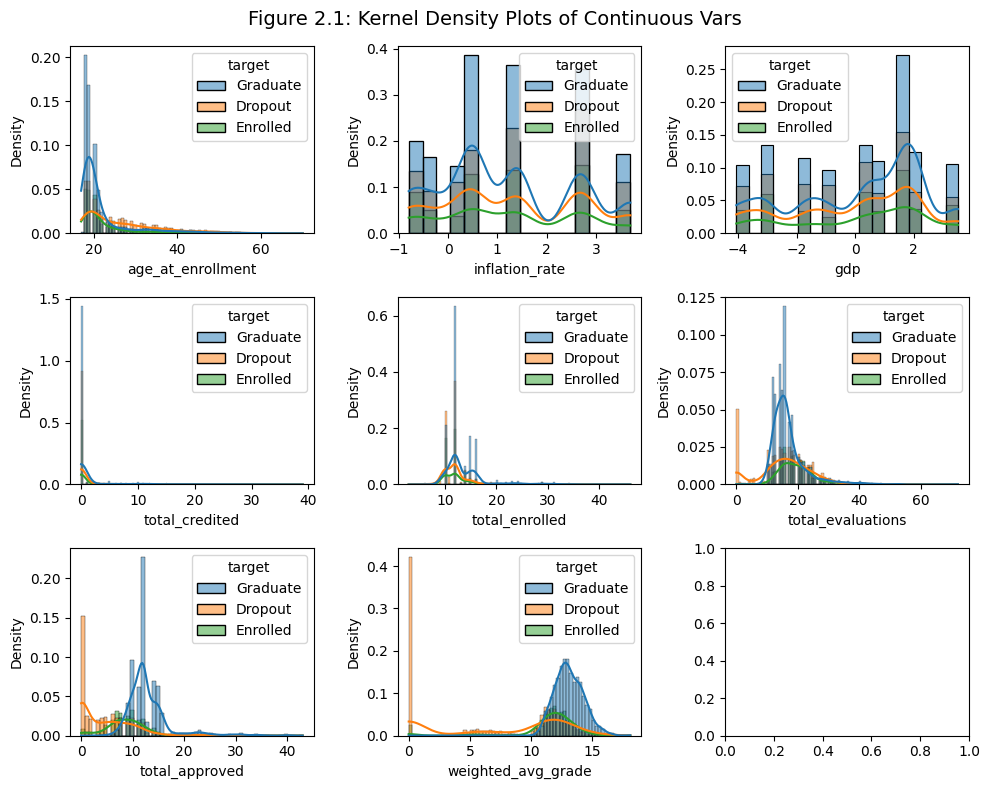


Summary metrics for numerical fields | Original Df
       age_at_enrollment  inflation_rate          gdp  total_credited  \
count        4244.000000     4244.000000  4244.000000     4244.000000   
mean           23.397738        1.229076     0.020895        1.304901   
std             7.684054        1.377679     2.272994        4.300778   
min            17.000000       -0.800000    -4.060000        0.000000   
25%            19.000000        0.300000    -1.700000        0.000000   
50%            20.000000        1.400000     0.320000        0.000000   
75%            25.000000        2.600000     1.790000        0.000000   
max            70.000000        3.700000     3.510000       39.000000   

       total_enrolled  total_evaluations  total_approved  weighted_avg_grade  
count     4244.000000        4244.000000      4244.00000         4244.000000  
mean        13.032988          17.056315         9.53016           10.917796  
std          3.902518           7.028871         5.77

In [19]:
# Kernel Density for new set of numerical fields
numeric_cols = decoded_engineered_df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(ncols=3, nrows=3, figsize=(10, 8))
x_counter = 0
y_counter = 0
for i, col in enumerate(numeric_cols):
    sns.histplot(data=decoded_engineered_df, x=col, hue='target', kde=True, stat="density", ax=axes[y_counter, x_counter])
    x_counter += 1
    if x_counter == 3:
        x_counter = 0
        y_counter += 1
    if i == len(numeric_cols) :
        break

fig.suptitle("Figure 2.1: Kernel Density Plots of Continuous Vars", fontsize=14)
plt.tight_layout()
plt.show()


print('\nSummary metrics for numerical fields | Original Df')
print(decoded_engineered_df.describe())

In [20]:
# calculate correlation on new params
X = decoded_engineered_df[numeric_cols]
corr = X.corr()
print('\n Correlation Heatmap | Extended Df')

# print values
corr_abs_sorted = corr.abs().unstack().sort_values(ascending=False)
corr_abs_sorted = corr_abs_sorted[corr_abs_sorted < 1]
print(corr_abs_sorted.head(20))



 Correlation Heatmap | Extended Df
total_credited      total_enrolled        0.847634
total_enrolled      total_credited        0.847634
                    total_approved        0.727657
total_approved      total_enrolled        0.727657
weighted_avg_grade  total_approved        0.712663
total_approved      weighted_avg_grade    0.712663
total_credited      total_approved        0.596262
total_approved      total_credited        0.596262
total_enrolled      total_evaluations     0.573881
total_evaluations   total_enrolled        0.573881
total_credited      total_evaluations     0.549156
total_evaluations   total_credited        0.549156
                    total_approved        0.464744
total_approved      total_evaluations     0.464744
total_evaluations   weighted_avg_grade    0.336677
weighted_avg_grade  total_evaluations     0.336677
                    age_at_enrollment     0.236791
age_at_enrollment   weighted_avg_grade    0.236791
total_credited      age_at_enrollment     0.21

In [21]:

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
print(vif_data)


              feature        VIF
0      total_enrolled  29.016713
1      total_approved  23.076827
2  weighted_avg_grade  22.414795
3   total_evaluations  12.657529
4   age_at_enrollment   9.181719
5      total_credited   2.972171
6      inflation_rate   1.820132
7                 gdp   1.029617



### 2.3 Grouping categories

The following section groups similar categories together to assist with dimensionality reduction.

In [22]:
# Group categories for marital status
combine_map = {
    "Married": "Married",
    "Widower": "Other",
    "Divorced": "Other",
    "Common-law marriage": "Married",
    "Legally separated": "Other",
}

# Apply the mapping to create a new column
decoded_engineered_df["marital_status_decoded"] = decoded_engineered_df["marital_status_decoded"].replace(combine_map)

print(decoded_engineered_df["marital_status_decoded"].unique())


['Single', 'Married', 'Other']
Categories (3, object): ['Other' < 'Married' < 'Single']


<positron-console-cell-22>:11: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [23]:
# Group categories for application mode
col = "application_mode_decoded"

combine_map = {
    "Change in course": "Change in institution/course",
    "Transfer": "Change in institution/course",
    "Change in institution/course": "Change in institution/course",
    "International student (bachelor)": "International student",
    "Change in institution/course (International)": "International student",
    "1st phase—general contingent": "1st phase",
    "1st phase—special contingent (Madeira Island)": "1st phase",
    "1st phase—special contingent (Azores Island)": "1st phase",
    "2nd phase—general contingent": "2nd phase",
    "3rd phase—general contingent": "3rd phase",
    "Technological specialization diploma holders": "Specialized diploma",
    "Short cycle diploma holders":  "Specialized diploma"
}
decoded_engineered_df[col] = decoded_engineered_df[col].replace(combine_map)

# group all others with less than 5% of samples
val_counts = decoded_engineered_df[col].value_counts()
val_percent = decoded_engineered_df[col].value_counts(normalize=True) * 100
to_group = val_percent[val_percent < 2].index
decoded_engineered_df[col] = decoded_engineered_df[col].replace(to_group, "Other")

print(pd.DataFrame({'Count': decoded_engineered_df[col].value_counts(normalize=True) }))



                                    Count
application_mode_decoded                 
1st phase                        0.386899
2nd phase                        0.198633
Over 23 years old                0.182846
Change in institution/course     0.102733
Specialized diploma              0.057022
Holders of other higher courses  0.032281
3rd phase                        0.028746
Other                            0.010839


<positron-console-cell-23>:18: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
<positron-console-cell-23>:24: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [24]:
# Group categories for major
col = "course_decoded"

combine_map = {
    "Management (evening attendance)": "Management",
    "Social Service (evening attendance)": "Social Service",
    "Basic Education": "Other",
    "Biofuel Production Technologies": "Other",
    "Communication Design": "Design and Multimedia",
    "Animation and Multimedia Design": "Design and Multimedia"
}

decoded_engineered_df[col] = decoded_engineered_df[col].replace(combine_map)

print(pd.DataFrame({'Count': decoded_engineered_df[col].value_counts(normalize=True) }))

                                         Count
course_decoded                                
Nursing                               0.180490
Management                            0.152686
Social Service                        0.134307
Veterinary Nursing                    0.079406
Journalism and Communication          0.077992
Advertising and Marketing Management  0.063148
Design and Multimedia                 0.061499
Tourism                               0.059378
Agronomy                              0.049482
Other                                 0.048068
Informatics Engineering               0.040057
Equiniculture                         0.033223
Oral Hygiene                          0.020264


<positron-console-cell-24>:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [25]:
# Group categories for prev qualification
col = "previous_qualification_decoded"

combine_map = {
    "Higher education—degree": "Higher education" ,
    "Higher education—bachelor’s degree": "Higher education",
    "Higher education—degree (1st cycle)": "Higher education",
    "Higher education—master’s degree": "Higher education",
    "Higher education—master’s degree (1st cycle)": "Higher education",
    "Higher education—master’s degree (2nd cycle)": "Higher education" ,
    "Higher education—doctorate": "Higher education" ,
    "Frequency of Higher Education": "Higher education",
    "Technological specialization course": "Specialized course",
    "Professional higher technical course": "Specialized course",
}

decoded_engineered_df[col] = decoded_engineered_df[col].replace(combine_map)
    
val_counts = decoded_engineered_df[col].value_counts()
val_percent = decoded_engineered_df[col].value_counts(normalize=True) * 100
to_group = val_counts[val_counts <= 100].index
decoded_engineered_df[col] = decoded_engineered_df[col].replace(to_group, "Other")

print(pd.DataFrame({'Count': decoded_engineered_df[col].value_counts(normalize=True) }))



                                                       Count
previous_qualification_decoded                              
Secondary education                                 0.836475
Specialized course                                  0.058435
Higher education                                    0.047361
Basic education 3rd cycle (9th/10th/11th year) ...  0.037700
Other                                               0.020028


<positron-console-cell-25>:17: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
<positron-console-cell-25>:22: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [26]:
# Group categories for nationality
col = "nationality_decoded"
 
val_counts = decoded_engineered_df[col].value_counts()
val_percent = decoded_engineered_df[col].value_counts(normalize=True) * 100
to_group = val_counts[val_percent < 2].index
decoded_engineered_df[col] = decoded_engineered_df[col].replace(to_group, "Other")

print(pd.DataFrame({'Count': decoded_engineered_df[col].value_counts(normalize=True) }))

                        Count
nationality_decoded          
Portuguese           0.375353
Angolan              0.198633
Santomean            0.182846
Brazilian            0.070924
Other                0.062441
Romanian             0.048775
Italian              0.032281
Cape Verdean         0.028746


<positron-console-cell-26>:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [27]:
# Group categories for parent's qualifications
col = "mothers_qualification_decoded"

combine_map = {
    "Higher Education—degree": "Higher education" ,
    "Higher Education—bachelor’s degree": "Higher education",
    "Higher Education—degree (1st cycle)": "Higher education",
    "Higher education—degree (1st cycle)": "Higher education",
    "Higher Education—master’s degree": "Higher education",
    "Higher Education—master’s degree (1st cycle)": "Higher education",
    "Higher Education—master’s degree (2nd cycle)": "Higher education" ,
    "Higher Education—doctorate": "Higher education",
    "Higher Education—doctorate (3rd cycle)": "Higher education",
    "Frequency of Higher Education": "Higher education",
    "2nd cycle of the general high school course": "Some High School",
    "Other—11th Year of Schooling": "Some High School",
    "12th Year of Schooling—not completed": "Some High School",
    "11th Year of Schooling—not completed": "Some High School",
    "10th Year of Schooling": "Some High School",
    "Complementary High School Course—not concluded": "Some High School",
    "2nd year complementary high school course": "Some High School",
    "Complementary High School Course": "Some High School",
    "9th Year of Schooling—not completed": "Some High School",
    "7th Year (Old)": "Basic education",
    "7th year of schooling": "Basic education",
    "8th year of schooling": "Basic education",
    "General Course of Administration and Commerce": "Specialized course",
    "General commerce course": "Specialized course",
    "Technological specialization course": "Specialized course",
    "Technical-professional course": "Specialized course",
    "Professional higher technical course": "Specialized course",
    "Specialized higher studies course": "Specialized course",
    "Supplementary Accounting and Administration": "Specialized course",
    "Can read without having a 4th year of schooling": "Basic education or less",
    "Cannot read or write": "Basic education or less",
    "Secondary Education—12th Year of Schooling or Equivalent": "Secondary Education"
}

decoded_engineered_df[col] = decoded_engineered_df[col].replace(combine_map)
decoded_engineered_df[col] = decoded_engineered_df[col].apply(
    lambda x: "Basic education or less" if "basic education" in str(x).lower() else x
)

print(pd.DataFrame({'Count': decoded_engineered_df[col].value_counts(normalize=True) }))

col = "fathers_qualification_decoded"
decoded_engineered_df[col] = decoded_engineered_df[col].replace(combine_map)
decoded_engineered_df[col] = decoded_engineered_df[col].apply(
    lambda x: "Basic education or less" if "basic education" in str(x).lower() else x
)

print(pd.DataFrame({'Count': decoded_engineered_df[col].value_counts(normalize=True) }))


<positron-console-cell-27>:39: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


                                  Count
mothers_qualification_decoded          
Specialized course             0.575165
Secondary Education            0.241282
Higher education               0.130537
Some High School               0.043827
Basic education or less        0.007540
Unknown                        0.001649
                                  Count
fathers_qualification_decoded          
Basic education or less        0.660933
Secondary Education            0.203582
Higher education               0.090952
Unknown                        0.026155
Some High School               0.011781
Specialized course             0.006598


<positron-console-cell-27>:47: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [28]:
# Group categories for parent's occupation
col = "mothers_occupation_decoded"

val_percent = decoded_engineered_df[col].value_counts(normalize=True) * 100
to_group = val_percent[val_percent < 5].index
decoded_engineered_df[col] = decoded_engineered_df[col].replace(to_group, "Other")

print(pd.DataFrame({'Count': decoded_engineered_df[col].value_counts(normalize=True) }))

col = "fathers_occupation_decoded"

val_percent = decoded_engineered_df[col].value_counts(normalize=True) * 100
to_group = val_percent[val_percent < 5].index
decoded_engineered_df[col] = decoded_engineered_df[col].replace(to_group, "Other")

print(pd.DataFrame({'Count': decoded_engineered_df[col].value_counts(normalize=True) }))

                                                       Count
mothers_occupation_decoded                                  
Unskilled Workers                                   0.357210
Administrative staff                                0.184967
Other                                               0.128181
Personal Services, Security and Safety Workers,...  0.119227
Intermediate Level Technicians and Professions      0.080113
Specialists in Intellectual and Scientific Acti...  0.069039
Skilled Workers in Industry, Construction, and ...  0.061263
                                                       Count
fathers_occupation_decoded                                  
Unskilled Workers                                   0.227144
Skilled Workers in Industry, Construction, and ...  0.151272
Other                                               0.142790
Personal Services, Security and Safety Workers,...  0.117342
Administrative staff                                0.088596
Intermediate Level Techn

<positron-console-cell-28>:6: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
<positron-console-cell-28>:14: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


<positron-console-cell-29>:25: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.


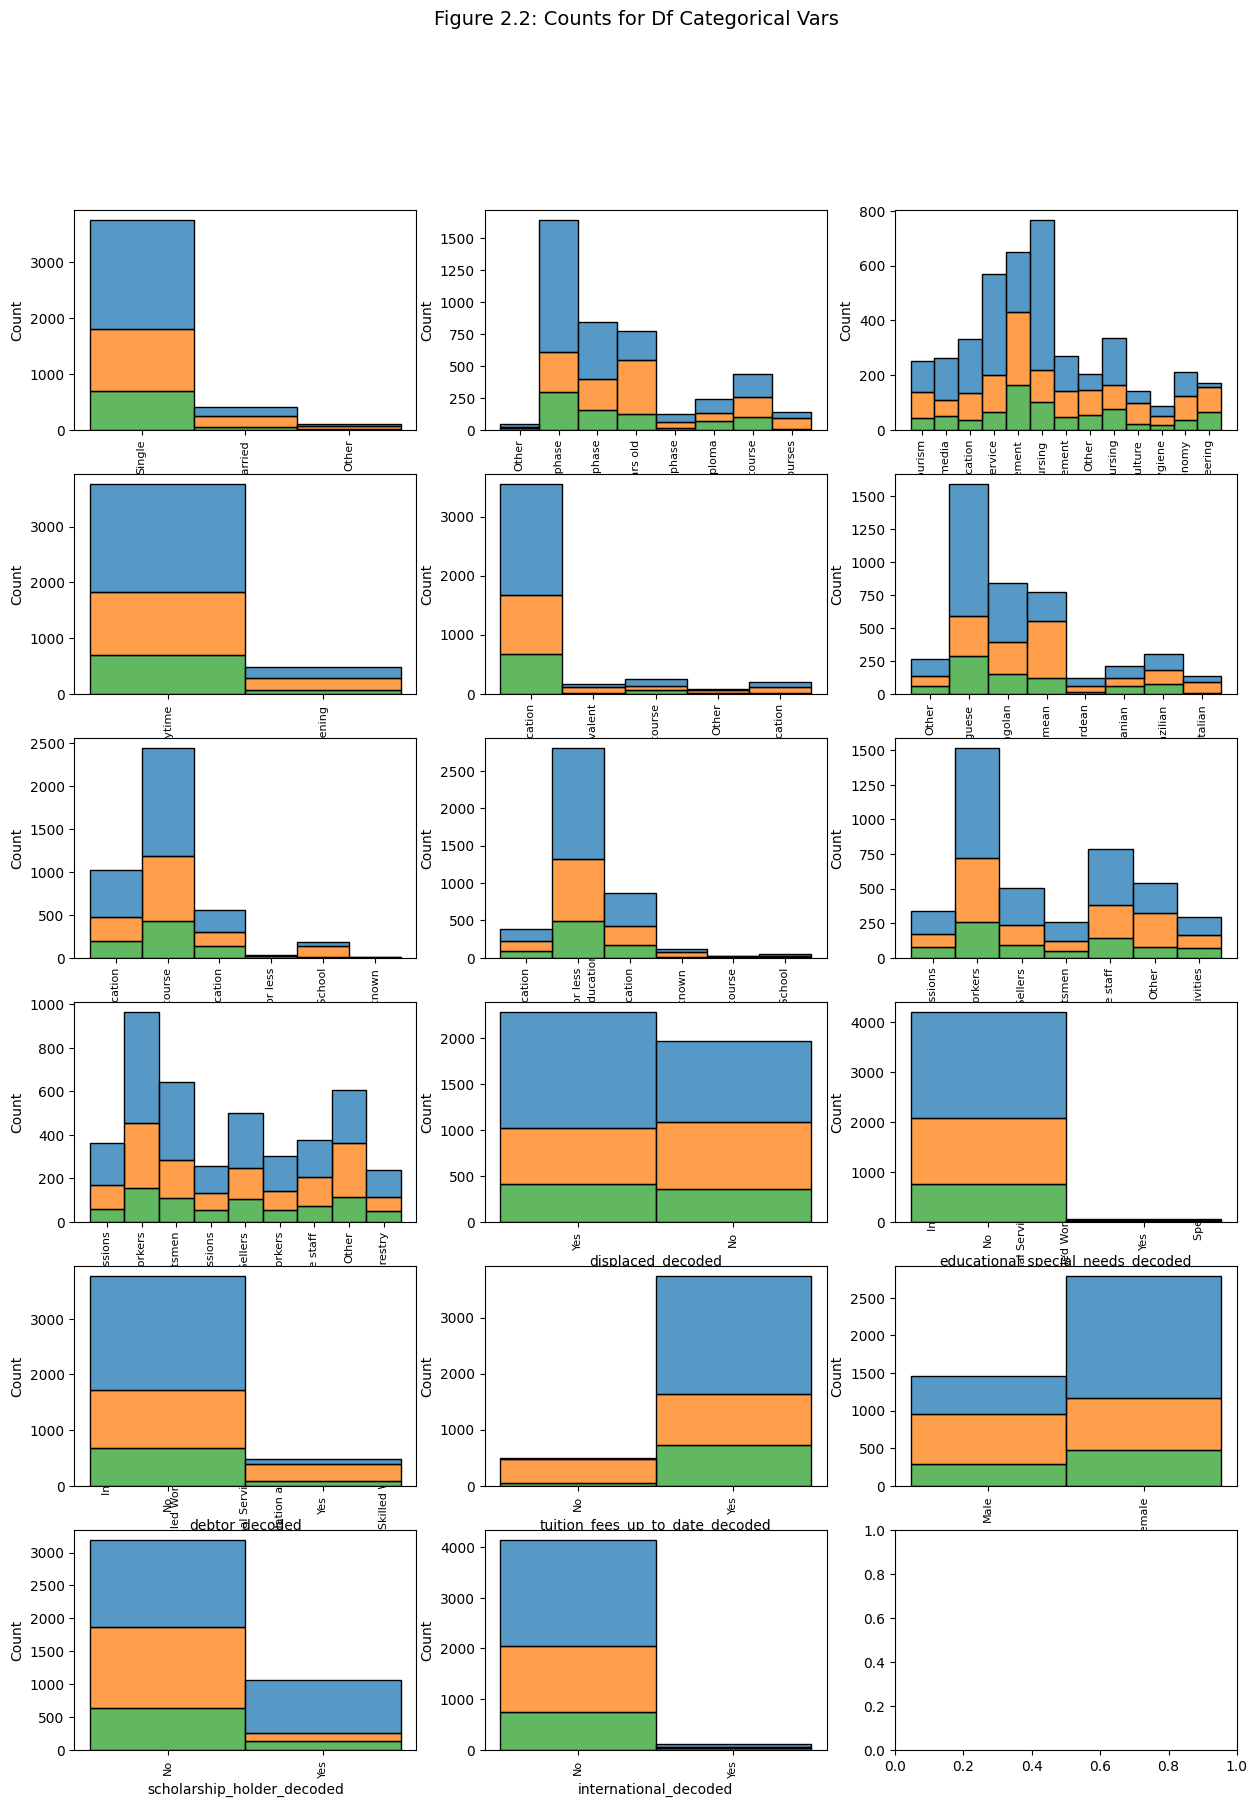

In [29]:
# print facetted barplots for new categorical values

max_cols = 3
max_rows = 6
fig_ori_dist, axes = plt.subplots(ncols=max_cols, nrows=max_rows, figsize=(15, 20))
categorical_cols_orginal.append('target')

x_counter = 0
y_counter = 0
for i, col in enumerate(categorical_cols_decoded):

    decoded_engineered_df[col] = decoded_engineered_df[col].astype('category')

    sns.histplot(data=decoded_engineered_df, x=decoded_engineered_df[col].astype(str), hue='target', ax=axes[y_counter, x_counter], multiple="stack")
    axes[y_counter, x_counter].tick_params(axis='x', labelsize=8, labelrotation=90)
    axes[y_counter, x_counter].get_legend().remove()
    x_counter += 1
    if x_counter == max_cols:
        x_counter = 0
        y_counter += 1
    if i == len(categorical_cols_decoded) :
        break

fig_ori_dist.suptitle("Figure 2.2: Counts for Df Categorical Vars", fontsize=14)
plt.tight_layout(pad=1)
plt.show()



### 2.4 What about Enrolled

18% of our observations are marked as in "enrolled", which is the student's current state. Keeping this class might make it harder to find the signals for dropout as students my drop out later. Therefore, we will reserve these observations as our inference dataset

In [30]:
# hold back enrolled students to reduce possible noise and use as inference df later
inference_df = decoded_engineered_df[decoded_engineered_df["target"] == 'Enrolled'].copy()
inference_df.drop(columns=['target'], inplace=True)


simplified_df = decoded_engineered_df[decoded_engineered_df["target"] != 'Enrolled'].copy()
# copy
simplified_df['y'] = simplified_df['target'].replace({'Graduate': 0, 'Dropout': 1}).astype('category')
simplified_df.drop(columns=['target'], inplace=True)

val_counts = simplified_df['y'].value_counts()
val_percent = simplified_df['y'].value_counts(normalize=True) * 100

print(pd.DataFrame({
    'Count': val_counts,
    'Percentage': val_percent.round(2) 
}))

   Count  Percentage
y                   
0   2134       61.36
1   1344       38.64


<positron-console-cell-30>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [31]:
print(simplified_df.columns)
simplified_df.to_csv("proccessed_dataset.csv", index=False)

Index(['age_at_enrollment', 'inflation_rate', 'gdp', 'marital_status_decoded',
       'application_mode_decoded', 'course_decoded',
       'daytimeevening_attendance_decoded', 'previous_qualification_decoded',
       'nationality_decoded', 'mothers_qualification_decoded',
       'fathers_qualification_decoded', 'mothers_occupation_decoded',
       'fathers_occupation_decoded', 'gender_decoded', 'displaced_decoded',
       'educational_special_needs_decoded', 'tuition_fees_up_to_date_decoded',
       'debtor_decoded', 'scholarship_holder_decoded', 'international_decoded',
       'total_credited', 'total_enrolled', 'total_evaluations',
       'total_approved', 'weighted_avg_grade', 'y'],
      dtype='object')


## 3. Model Training

### 3.0 - Base Model (Decision Tree)

In [32]:
# split our data
X = simplified_df.drop(['y'], axis=1)
y = simplified_df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13, stratify=y)

# reset categorical_cols
categorical_cols = categorical_cols_decoded

# define our preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
], remainder='drop')

# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=13))
])

# Fit
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)


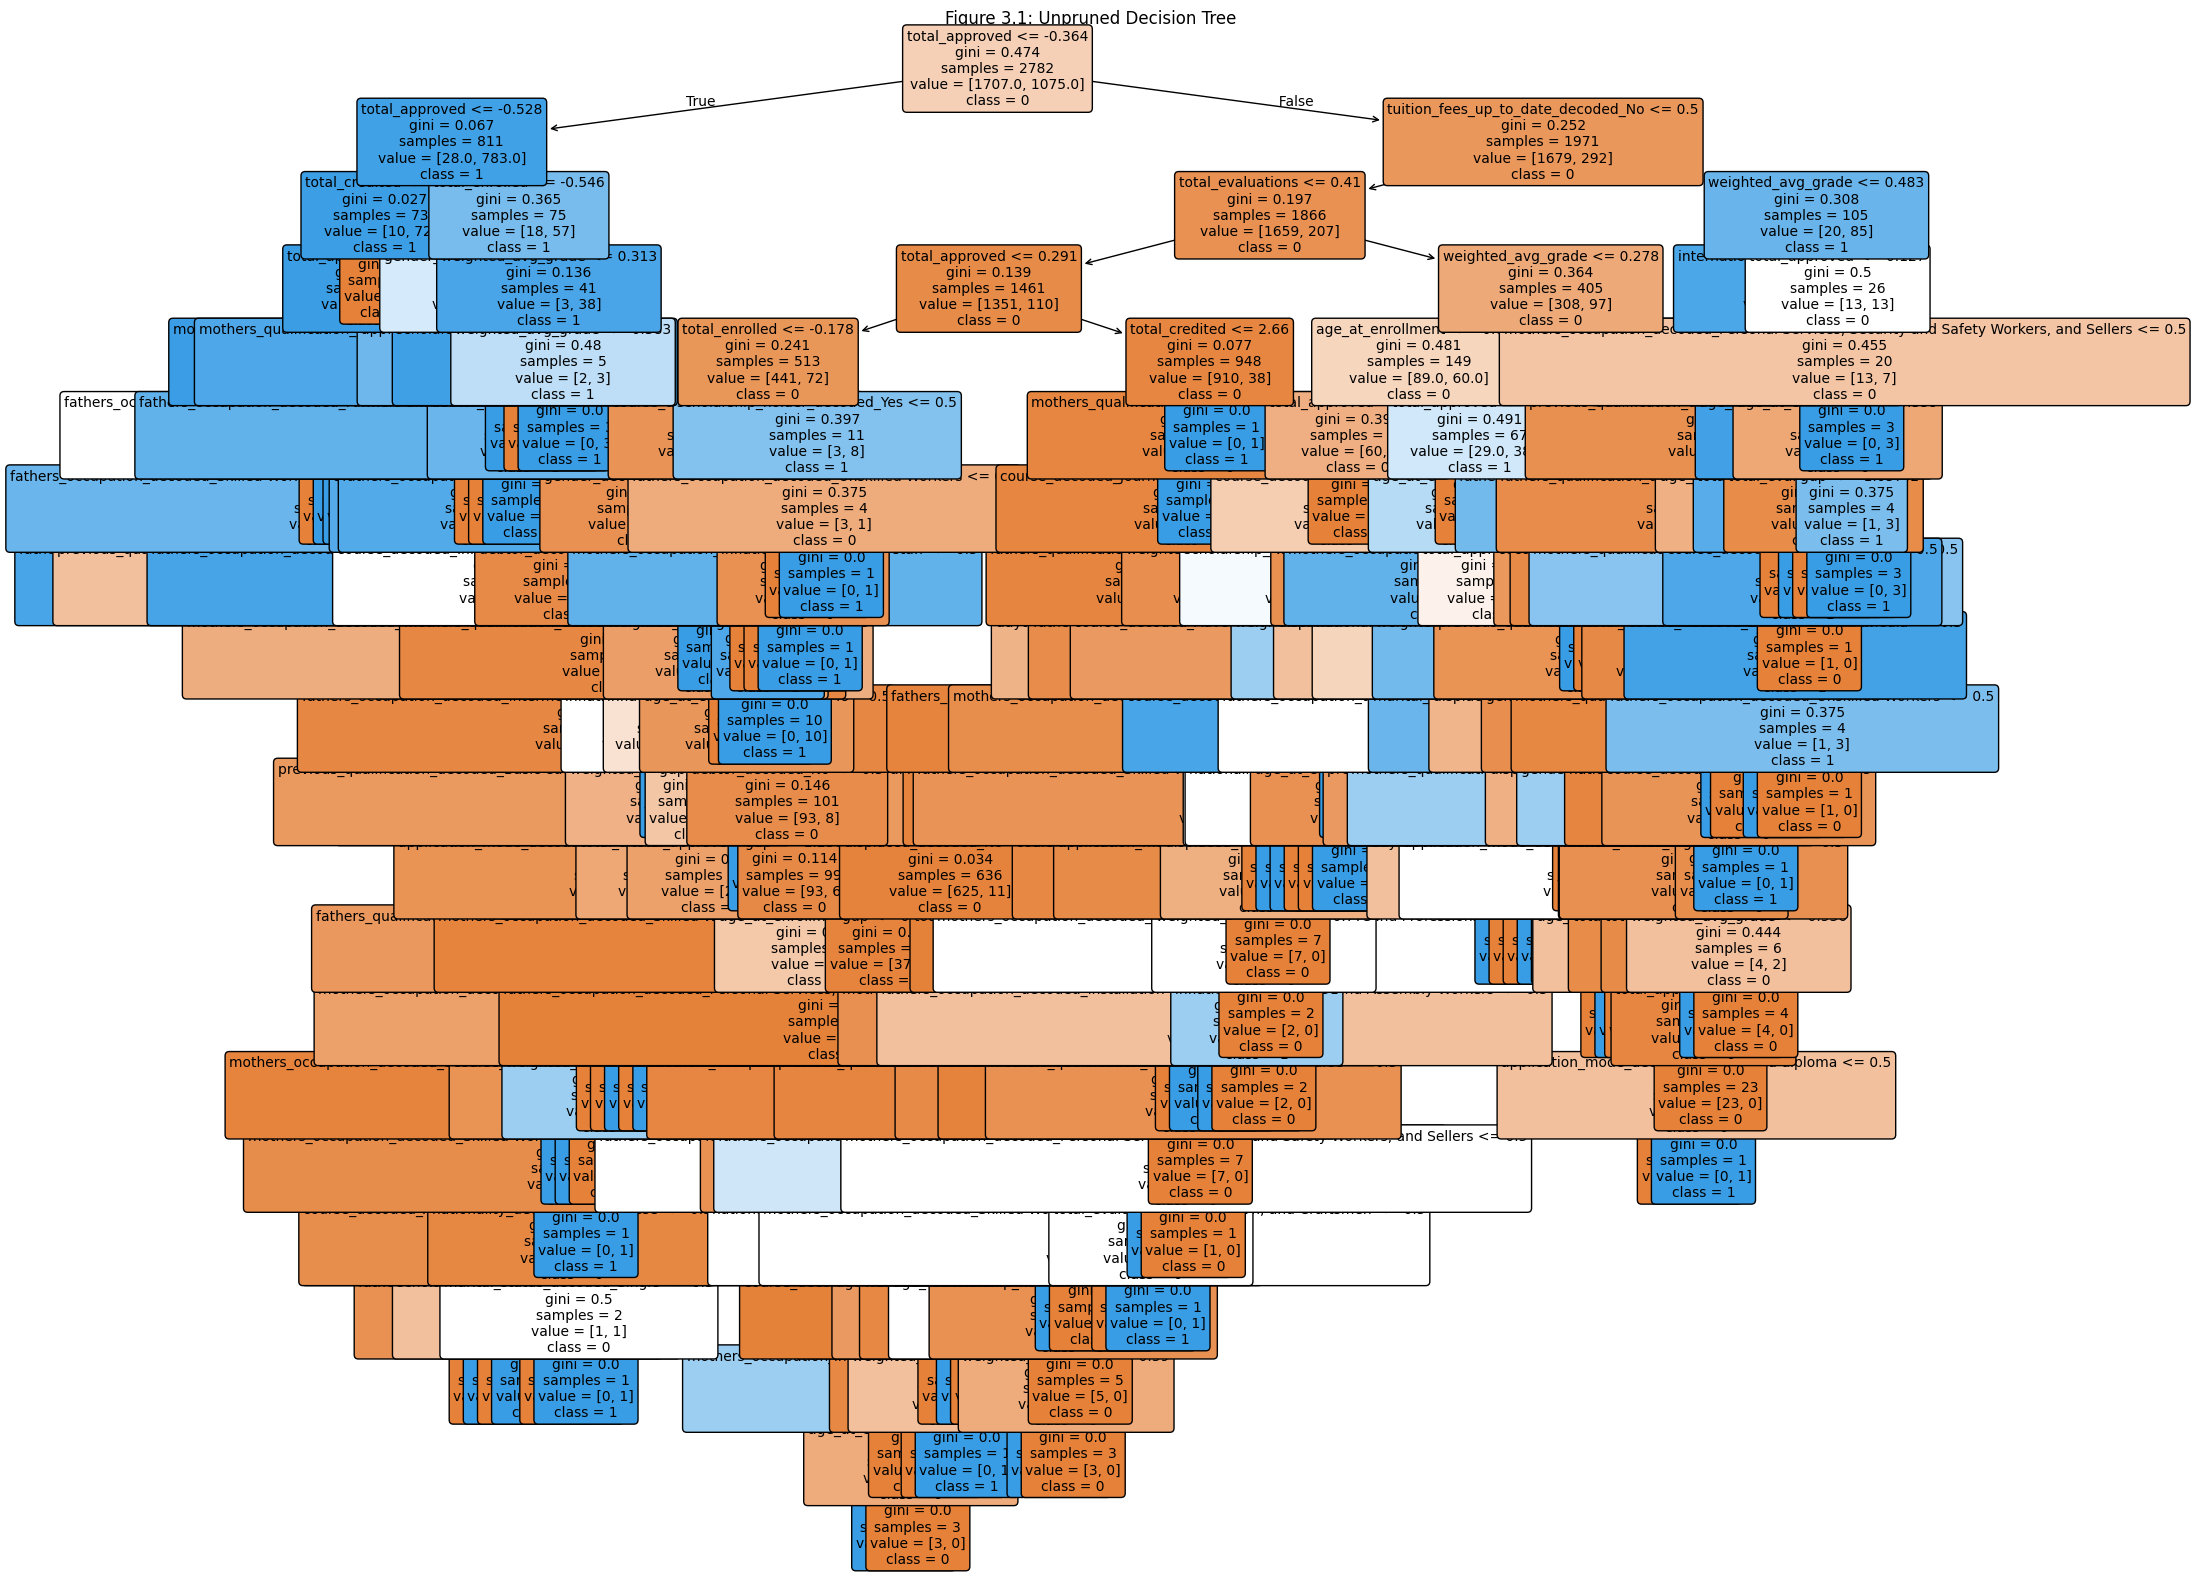

In [33]:
# plot unpruned decision tree
categorical_features = pipeline.named_steps['preprocessor']\
                .named_transformers_['cat']\
                .get_feature_names_out(categorical_cols)

plt.figure(figsize=(20,20))
plot_tree(
    pipeline.named_steps['classifier'],
    feature_names=list(numeric_cols) + list(categorical_features),
    class_names=pipeline.named_steps['classifier'].classes_.astype(str),
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title('Figure 3.1: Unpruned Decision Tree')
plt.show()

Best max_depth: 2


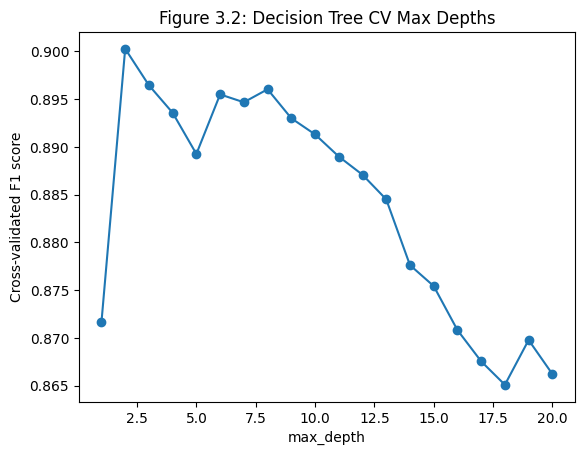

In [34]:
max_depths = range(1, 21)
cv_scores = []

for depth in max_depths:
   
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=depth, random_state=13))
    ])

    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_macro') 
    cv_scores.append(np.mean(scores))

# Find the best depth
best_depth = max_depths[np.argmax(cv_scores)]
print("Best max_depth:", best_depth)

# Optional: plot performance vs depth
import matplotlib.pyplot as plt

plt.plot(max_depths, cv_scores, marker='o')
plt.title('Figure 3.2: Decision Tree CV Max Depths')
plt.xlabel('max_depth')
plt.ylabel('Cross-validated F1 score')
plt.show()

Train score: 0.9406901509705248


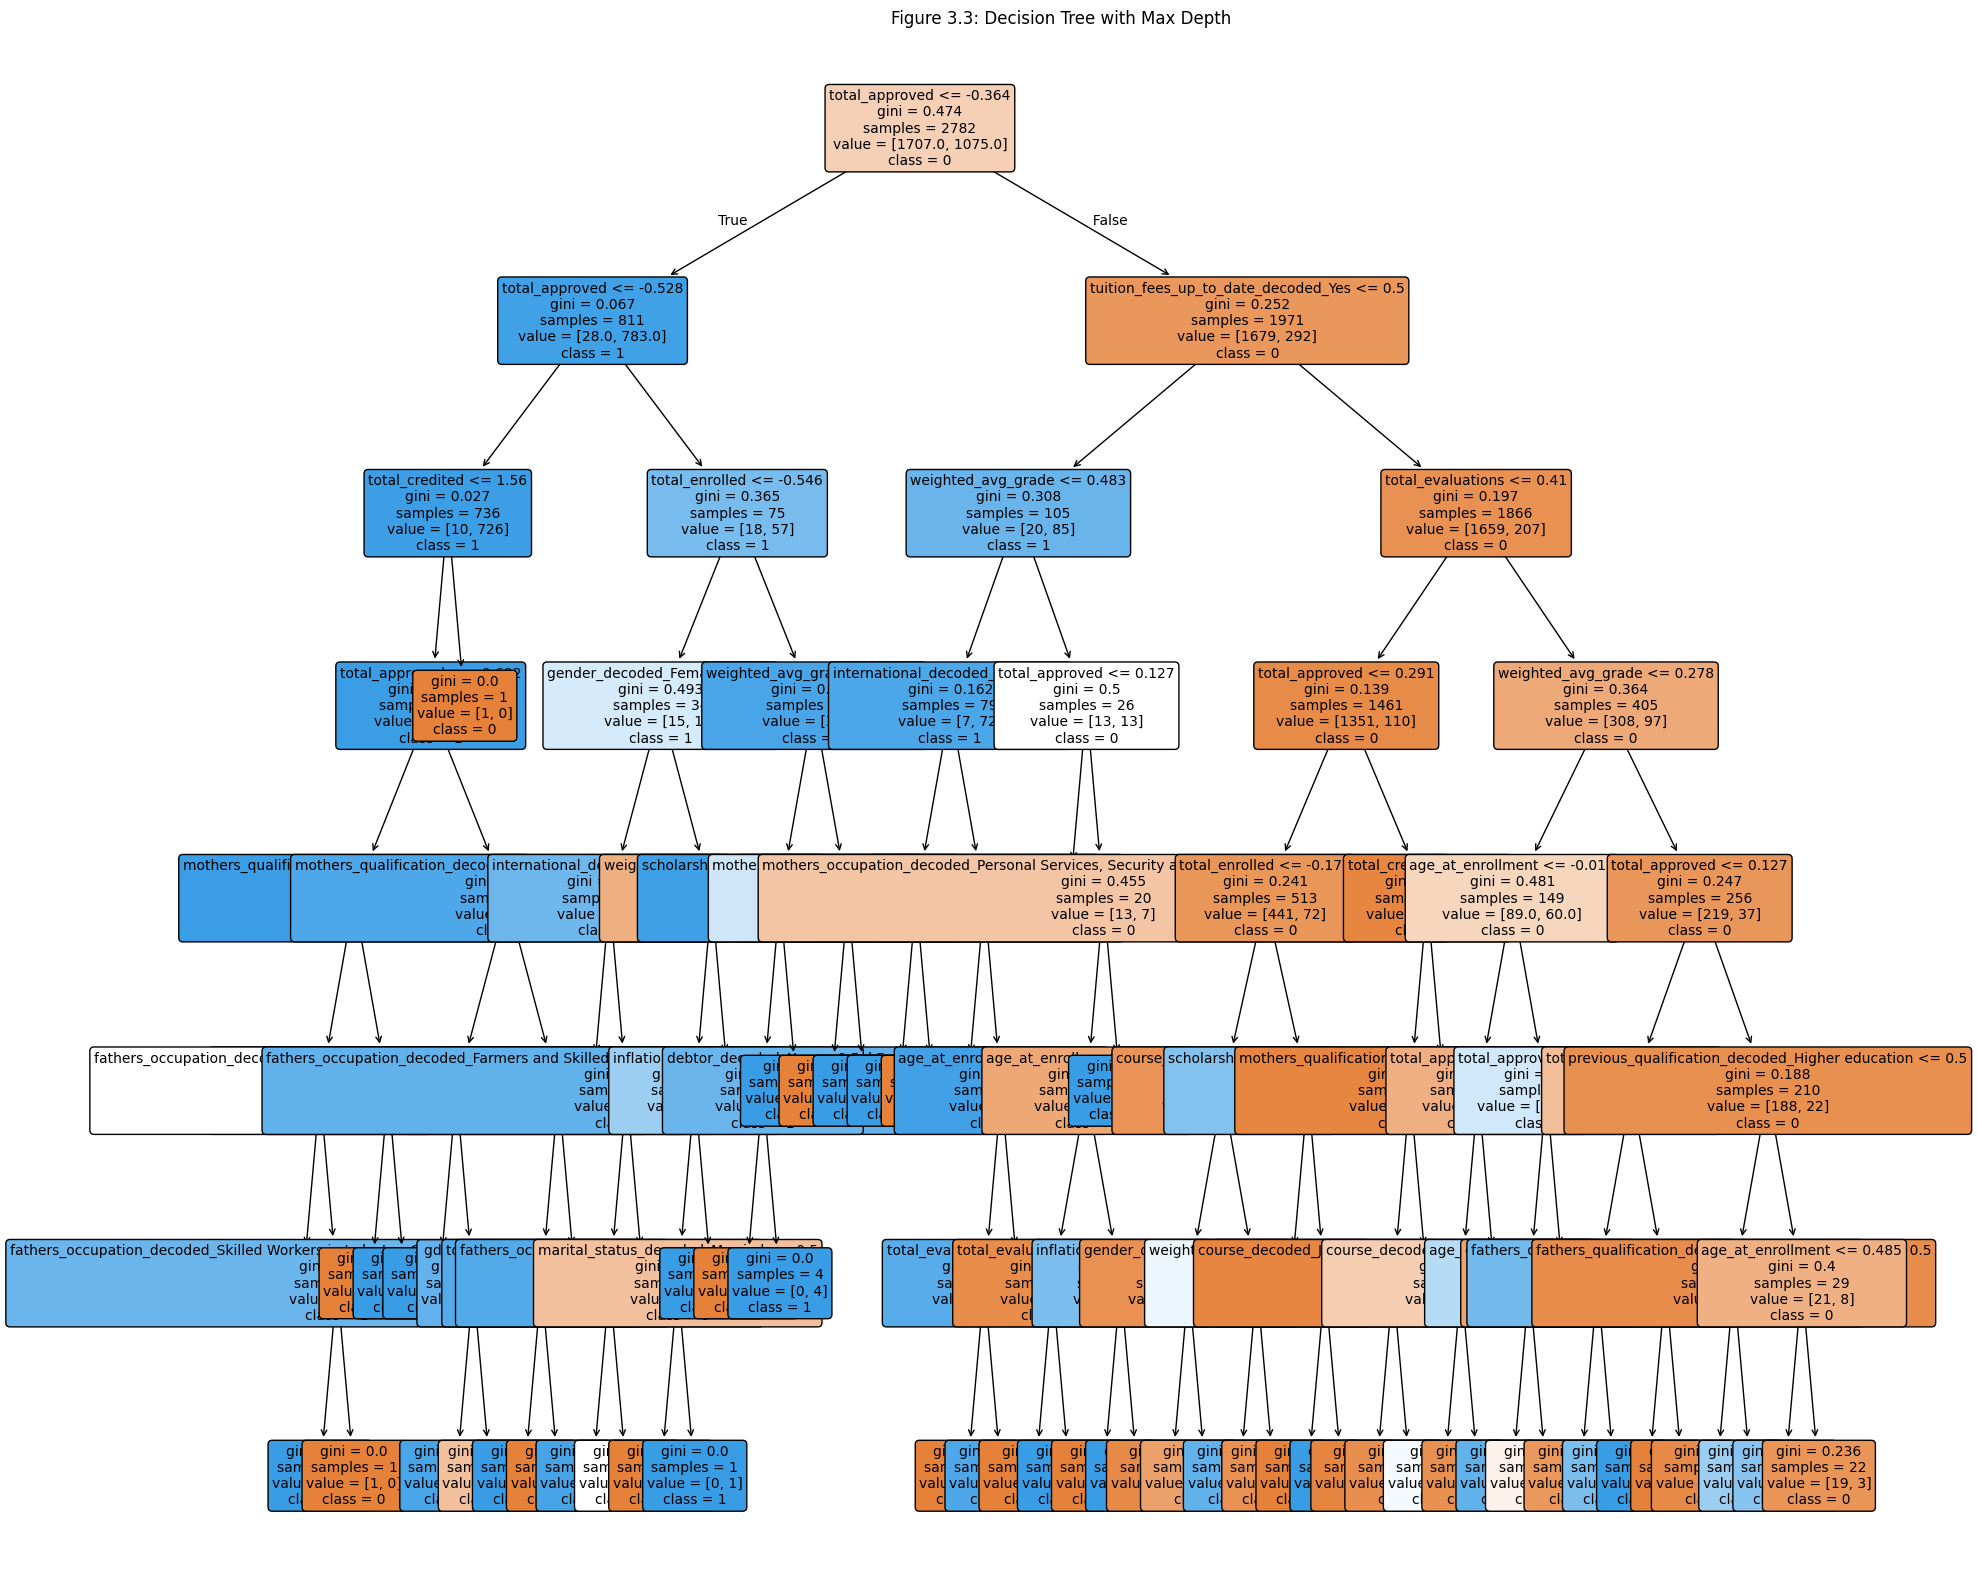

In [35]:
dt_model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=7, random_state=13))
    ])
dt_model.fit(X_train, y_train)
print("Train score:", dt_model.score(X_train, y_train))

plt.figure(figsize=(20,20))
plot_tree(
    dt_model.named_steps['classifier'],
    feature_names=list(numeric_cols) + list(categorical_features),
    class_names=dt_model.named_steps['classifier'].classes_.astype(str),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Figure 3.3: Decision Tree with Max Depth')
plt.show()


In [36]:
# Evaluation Metrics
eval_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Prec', 'Recall', 'F1', 'AUC', 'AUPRC'])

# helper to create evaluation table
def append_eval(model_name, y_true, preds, probs):

    return  pd.concat([eval_df, pd.DataFrame([{
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, preds),
        'Prec': precision_score(y_true, preds, zero_division=0),
        'Recall': recall_score(y_true, preds, zero_division=0),
        'F1': f1_score(y_true, preds, zero_division=0),
        'AUC': roc_auc_score(y_true, probs),
        'AUPRC': average_precision_score(y_true, probs)
    }])], ignore_index=True)


def evaluate_model(model, model_name):
    global X_test, y_test, eval_df

    print(f'\n{model_name}\n'),

    # print matrix
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f'Confusion Matrix for {model_name}\n', confusion_matrix(y_test, y_pred))
    print(f"\nClassification Report for {model_name}:\n", classification_report(y_test, y_pred))

    # print top ten
    clf = model.named_steps['classifier']
    # and callable(getattr(clf, 'feature_importances_'))
    if (hasattr(clf, 'feature_importances_')):
        preprocessor = model.named_steps['preprocessor']
        features = pd.DataFrame(
            clf.feature_importances_,
            index=preprocessor.get_feature_names_out(),
            columns=['importance']
        )

        print(f'\nTop Features \n', features.sort_values(by='importance', ascending=False).head(20))


    return append_eval(model_name, y_test, y_pred, y_proba)



In [37]:
eval_df = evaluate_model(dt_model, model_name="Decision Tree")


Decision Tree

Confusion Matrix for Decision Tree
 [[410  17]
 [ 61 208]]

Classification Report for Decision Tree:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91       427
           1       0.92      0.77      0.84       269

    accuracy                           0.89       696
   macro avg       0.90      0.87      0.88       696
weighted avg       0.89      0.89      0.89       696


Top Features 
                                                     importance
num__total_approved                                   0.756530
cat__tuition_fees_up_to_date_decoded_Yes              0.091943
num__weighted_avg_grade                               0.033225
num__total_evaluations                                0.021112
num__total_enrolled                                   0.016436
num__age_at_enrollment                                0.016337
cat__course_decoded_Other                             0.006524
cat__gender_decoded_Female         

<positron-console-cell-37>:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


### 3.1 Random Forest

Chose Random Forest on account of its ability to 

In [38]:
# degine preprocessor for rf
preprocessor2 = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
            ('standardizer', StandardScaler())
        ]), numeric_cols)
    ], remainder='drop'
)



# Build base model
rf0_model = ImbPipeline([
    ('preprocessor', preprocessor2),
    ('smote', SMOTE(random_state=13)),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=13,
        oob_score=True,
        n_jobs=-1
    ))
])

rf0_model.fit(X_train, y_train)

scores = cross_val_score(rf0_model, X_train, y_train, cv=10, scoring='f1_macro')
print("Mean F1-macro CV score:", scores.mean())

eval_df = evaluate_model(rf0_model, model_name="RF0")


categorical_features = rf0_model.named_steps['preprocessor']\
                .named_transformers_['cat']\
                .get_feature_names_out(categorical_cols)

Mean F1-macro CV score: 0.9152306609485515

RF0

Confusion Matrix for RF0
 [[410  17]
 [ 56 213]]

Classification Report for RF0:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92       427
           1       0.93      0.79      0.85       269

    accuracy                           0.90       696
   macro avg       0.90      0.88      0.89       696
weighted avg       0.90      0.90      0.89       696


Top Features 
                                           importance
num__total_approved                         0.244423
num__weighted_avg_grade                     0.164848
num__total_evaluations                      0.051600
cat__tuition_fees_up_to_date_decoded_Yes    0.050928
cat__tuition_fees_up_to_date_decoded_No     0.046591
num__age_at_enrollment                      0.035457
num__total_enrolled                         0.027138
cat__scholarship_holder_decoded_No          0.024166
cat__scholarship_holder_decoded_Yes         0.022

In [39]:
# loop through list of estimators and perform 5 k-Fold cross validation

oobScores_gini = []
oobScores_ent = []
oobScores_cv = []
oobScores_cv_ent = []

n_estimator = list(range(50, 501, 50))

for n in n_estimator:
    
    rf_pipe = ImbPipeline([
         ('preprocessor', preprocessor2),
        ('smote', SMOTE(random_state=13)),
        ('classifier', RandomForestClassifier(
            n_estimators=n,
            random_state=13,
            oob_score=True,
            max_depth=23, 
            min_samples_leaf=2, 
            min_samples_split=7,
            n_jobs=-1
        ))
    ])

    rf_pipe_ent = ImbPipeline([
         ('preprocessor', preprocessor2),
        ('smote', SMOTE(random_state=13)),
        ('classifier', RandomForestClassifier(
            n_estimators=n,
            criterion='entropy', 
            random_state=13,
            oob_score=True,
            max_depth=23, 
            min_samples_leaf=2, 
            min_samples_split=7,
            n_jobs=-1
        ))
    ])

    # Train our model Using 'gini'
    rf_pipe.fit(X_train, y_train)
    oobScores_gini.append(rf_pipe.named_steps['classifier'].oob_score_)

    # Cross Validate
    scores = cross_val_score(rf_pipe, X_train, y_train, cv=10)
    oobScores_cv.append(scores.mean())

    # Train our model Using 'entropy'
    rf_pipe_ent.fit(X_train, y_train)
    oobScores_ent.append(rf_pipe_ent.named_steps['classifier'].oob_score_)

    # Cross Validate
    scores = cross_val_score(rf_pipe_ent, X_train, y_train, cv=10)
    oobScores_cv_ent.append(scores.mean())




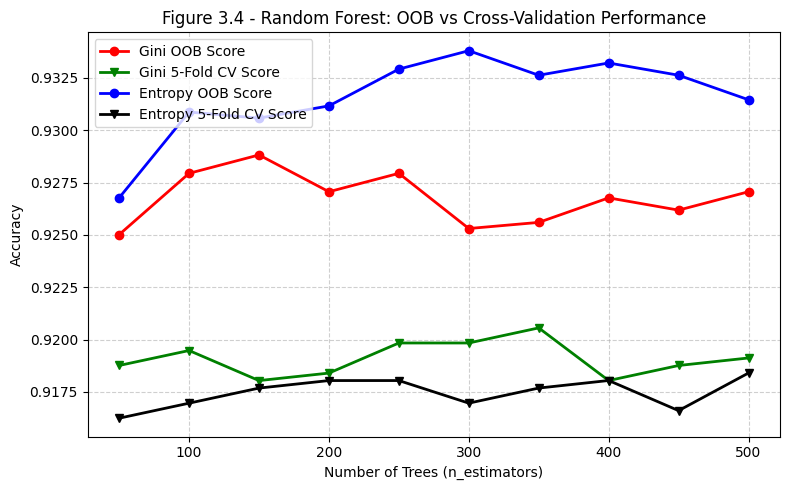

In [40]:
# plot results from previous step
plt.figure(figsize=(8, 5))
plt.plot(n_estimator, oobScores_gini, color='red', marker='o',  label='Gini OOB Score', linewidth=2)
plt.plot(n_estimator, oobScores_cv,  color='green', marker='v', label='Gini 5-Fold CV Score', linewidth=2)
plt.plot(n_estimator, oobScores_ent, color='blue', marker='o',  label='Entropy OOB Score', linewidth=2)
plt.plot(n_estimator, oobScores_cv_ent,  color='black', marker='v', label='Entropy 5-Fold CV Score', linewidth=2)
plt.title('Figure 3.4 - Random Forest: OOB vs Cross-Validation Performance')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [41]:

# print comparison table
cv_df = pd.DataFrame({ 'n_estimator' : n_estimator, 'Gini 5-Fold CV Score' : oobScores_cv })
gini_df = pd.DataFrame({ 'n_estimator' : n_estimator, 'Gini' : oobScores_gini })
ent_df = pd.DataFrame({ 'n_estimator' : n_estimator, 'Ent' : oobScores_ent })
ent_cv_df = pd.DataFrame({ 'n_estimator' : n_estimator, 'Ent 5-Fold CV Score' : oobScores_cv_ent })
oob_scores = pd.merge(cv_df, ent_cv_df, left_on='n_estimator', right_on='n_estimator', how='left')
oob_scores = pd.merge(ent_df, oob_scores, left_on='n_estimator', right_on='n_estimator', how='left')
oob_scores = pd.merge(gini_df, oob_scores, left_on='n_estimator', right_on='n_estimator', how='left')
print('\nTable 3.1: OBB Score Differences by criterion \n', oob_scores)



Table 3.1: OBB Score Differences by criterion 
    n_estimator      Gini       Ent  Gini 5-Fold CV Score  Ent 5-Fold CV Score
0           50  0.925015  0.926772              0.918764             0.916246
1          100  0.927944  0.930873              0.919480             0.916964
2          150  0.928822  0.930580              0.918044             0.917685
3          200  0.927065  0.931166              0.918402             0.918045
4          250  0.927944  0.932923              0.919840             0.918045
5          300  0.925308  0.933802              0.919840             0.916966
6          350  0.925600  0.932630              0.920560             0.917686
7          400  0.926772  0.933216              0.918045             0.918047
8          450  0.926186  0.932630              0.918764             0.916609
9          500  0.927065  0.931459              0.919124             0.918406


In [42]:
# retrain model using max depth from above

rf0_pipe = ImbPipeline([
    ('preprocessor', preprocessor2),
    ('smote', SMOTE(random_state=13)),
    ('rf', RandomForestClassifier(
        n_estimators=400,
        criterion='entropy', 
        random_state=13,
        oob_score=True,
        n_jobs=-1
    ))
])


# lets get the best depth
param_dist = {
    'rf__max_depth': randint(2, 40),           
    'rf__min_samples_split': randint(2, 20),
    'rf__min_samples_leaf': randint(1, 10),
    'rf__max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    estimator=rf0_pipe,
    param_distributions=param_dist,
    n_iter=40,                     
    scoring='f1_macro',          
    cv=5,
    random_state=13,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best score:", random_search.best_score_)
best_depth = random_search.best_params_['rf__max_depth']

Best params: {'rf__max_depth': 37, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 6}
Best score: 0.9171243843922772


In [43]:
# train using the above
rf_model = ImbPipeline([
    ('preprocessor', preprocessor2),
    ('smote', SMOTE(random_state=13)),
    ('classifier', RandomForestClassifier(
        n_estimators=400,
        criterion='entropy', 
        random_state=13,
        oob_score=True,
        max_depth=38, 
        min_samples_leaf=2, 
        min_samples_split=5,
        n_jobs=-1
    ))
])


rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
# Evaluate Model
eval_df = evaluate_model(rf_model, model_name="RF1")


RF1

Confusion Matrix for RF1
 [[416  11]
 [ 61 208]]

Classification Report for RF1:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92       427
           1       0.95      0.77      0.85       269

    accuracy                           0.90       696
   macro avg       0.91      0.87      0.89       696
weighted avg       0.90      0.90      0.89       696


Top Features 
                                           importance
num__total_approved                         0.255090
num__weighted_avg_grade                     0.166490
cat__tuition_fees_up_to_date_decoded_No     0.058266
num__total_evaluations                      0.056624
cat__tuition_fees_up_to_date_decoded_Yes    0.047320
num__age_at_enrollment                      0.032538
num__total_enrolled                         0.027729
cat__scholarship_holder_decoded_No          0.024248
cat__scholarship_holder_decoded_Yes         0.023167
num__gdp                               

### 3.2 XGBoost

In [45]:
# XGBoost

xgb0_pipe = ImbPipeline([
    ('preprocessor', preprocessor2),
    ('smote', SMOTE(random_state=13)),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        eval_metric='logloss',
        random_state=13
    ))
])

xgb0_pipe.fit(X_train, y_train)

scores = cross_val_score(xgb0_pipe, X_train, y_train, cv=10, scoring='f1_macro')
print("Mean F1-macro CV score:", scores.mean())

# Evaluate Model
eval_df = evaluate_model(xgb0_pipe, model_name="XG0")

Mean F1-macro CV score: 0.9187645715047094

XG0

Confusion Matrix for XG0
 [[412  15]
 [ 51 218]]

Classification Report for XG0:
               precision    recall  f1-score   support

           0       0.89      0.96      0.93       427
           1       0.94      0.81      0.87       269

    accuracy                           0.91       696
   macro avg       0.91      0.89      0.90       696
weighted avg       0.91      0.91      0.90       696


Top Features 
                                                     importance
num__total_approved                                   0.162985
cat__tuition_fees_up_to_date_decoded_No               0.104646
cat__course_decoded_Informatics Engineering           0.032391
cat__course_decoded_Other                             0.030273
num__total_enrolled                                   0.024999
cat__course_decoded_Equiniculture                     0.024214
cat__course_decoded_Management                        0.021166
cat__scholarship_holde

In [46]:
# Use RandomSearch to Tune 
param_dist = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [3, 4, 5, 6, 8],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.6, 0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'classifier__min_child_weight': [1, 3, 5, 7],
    'classifier__gamma': [0, 0.1, 0.3, 0.5],
    'classifier__reg_lambda': [1, 1.5, 2, 5, 10],
    'classifier__reg_alpha': [0, 0.1, 0.5, 1],
}


random_search = RandomizedSearchCV(
    estimator=xgb0_pipe,
    param_distributions=param_dist,
    n_iter=20,                
    scoring='f1_macro',      
    cv=10,
    verbose=2,
    n_jobs=-1,
    random_state=13
)

# === Fit Search ===
random_search.fit(X_train, y_train)

print("Best score:", random_search.best_score_)
print("Best params:", random_search.best_params_)



Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best score: 0.9221388312329102
Best params: {'classifier__subsample': 0.8, 'classifier__reg_lambda': 1.5, 'classifier__reg_alpha': 0.5, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 1, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.05, 'classifier__gamma': 0.5, 'classifier__colsample_bytree': 0.7}


In [47]:
# Evaluate Model
xgb1_model = random_search.best_estimator_
eval_df = evaluate_model(xgb1_model, model_name="XG1")


XG1

Confusion Matrix for XG1
 [[415  12]
 [ 54 215]]

Classification Report for XG1:
               precision    recall  f1-score   support

           0       0.88      0.97      0.93       427
           1       0.95      0.80      0.87       269

    accuracy                           0.91       696
   macro avg       0.92      0.89      0.90       696
weighted avg       0.91      0.91      0.90       696


Top Features 
                                                     importance
num__total_approved                                   0.135221
cat__tuition_fees_up_to_date_decoded_No               0.105564
num__weighted_avg_grade                               0.043038
cat__tuition_fees_up_to_date_decoded_Yes              0.034203
cat__course_decoded_Informatics Engineering           0.027454
cat__debtor_decoded_Yes                               0.025941
cat__course_decoded_Other                             0.024485
num__total_evaluations                                0.022807
nu

In [48]:
# Test different learning rates
from sklearn.base import clone

results = []
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3]

for lr in learning_rates:

    model = clone(xgb1_model)
    model.set_params(classifier__learning_rate=lr)

    scores = cross_validate(
        model,
        X_train, y_train,
        cv=5,
        scoring={
            "accuracy": "accuracy",
            "recall_yes": make_scorer(recall_score, pos_label=1),
            "f1_yes": make_scorer(f1_score, pos_label=1)
        },
        n_jobs=-1
    )
    
    results.append({
        "learning_rate": lr,
        "accuracy": scores["test_accuracy"].mean(),
        "recall_yes": scores["test_recall_yes"].mean(),
        "f1_yes": scores["test_f1_yes"].mean()
    })

df_lr = pd.DataFrame(results).sort_values("learning_rate", ascending=True)
print(df_lr)

   learning_rate  accuracy  recall_yes    f1_yes
0          0.001  0.912658    0.829767  0.880081
1          0.010  0.918409    0.835349  0.887745
2          0.050  0.926675    0.861395  0.900649
3          0.100  0.925238    0.862326  0.899024
4          0.200  0.922722    0.857674  0.895578
5          0.300  0.921284    0.860465  0.894098


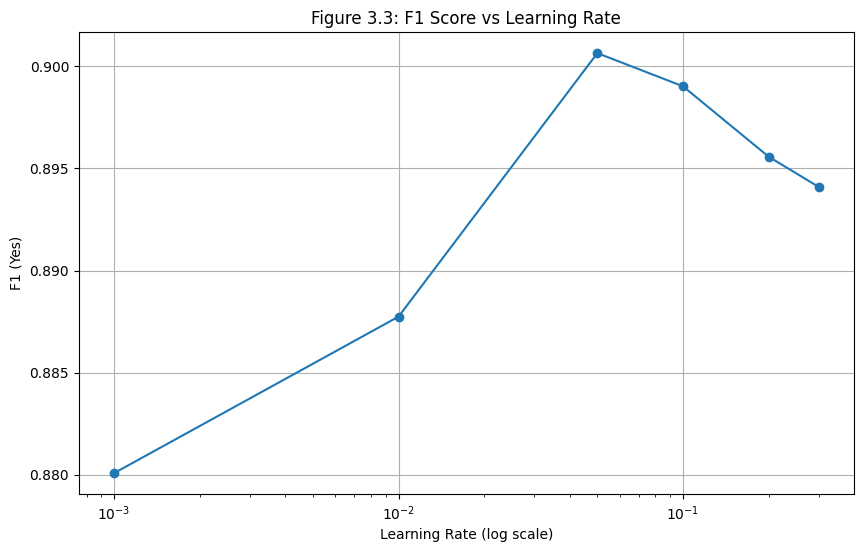

In [49]:
# Plot learning rates
plt.figure(figsize=(10,6))
plt.plot(df_lr["learning_rate"], df_lr["f1_yes"], marker="o")
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("F1 (Yes)")
plt.title("Figure 3.3: F1 Score vs Learning Rate")
plt.grid(True)
plt.show()


In [50]:
xgb2_model = clone(xgb1_model)
xgb2_model.set_params(classifier__learning_rate=0.050)
xgb2_model.fit(X_train, y_train)
eval_df = evaluate_model(xgb2_model, model_name="XG2")



XG2

Confusion Matrix for XG2
 [[415  12]
 [ 54 215]]

Classification Report for XG2:
               precision    recall  f1-score   support

           0       0.88      0.97      0.93       427
           1       0.95      0.80      0.87       269

    accuracy                           0.91       696
   macro avg       0.92      0.89      0.90       696
weighted avg       0.91      0.91      0.90       696


Top Features 
                                                     importance
num__total_approved                                   0.135221
cat__tuition_fees_up_to_date_decoded_No               0.105564
num__weighted_avg_grade                               0.043038
cat__tuition_fees_up_to_date_decoded_Yes              0.034203
cat__course_decoded_Informatics Engineering           0.027454
cat__debtor_decoded_Yes                               0.025941
cat__course_decoded_Other                             0.024485
num__total_evaluations                                0.022807
nu

### 3.3 SVM With PCA

SVN doesn't like it when columns are highly correlated. 

In [51]:
pca_cols = [
    'total_enrolled',
    'total_credited',
    'total_approved',
    'total_evaluations',
    'weighted_avg_grade'
]

other_numeric_cols = [col for col in numeric_cols if col not in pca_cols]

preprocessor3 =  ColumnTransformer(
    transformers=[
        ('pca_group', Pipeline([ 
            ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=0.95))
        ]), pca_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols),
        
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
            ('standardizer', StandardScaler())
        ]), other_numeric_cols)
    ],
    remainder='drop'
)

svm0_pipe = Pipeline([
    ('preprocessor', preprocessor3),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True))
])

svm0_pipe.fit(X_train, y_train)

# Show model metrics
eval_df = evaluate_model(svm0_pipe, model_name="SVM0")



SVM0

Confusion Matrix for SVM0
 [[417  10]
 [ 59 210]]

Classification Report for SVM0:
               precision    recall  f1-score   support

           0       0.88      0.98      0.92       427
           1       0.95      0.78      0.86       269

    accuracy                           0.90       696
   macro avg       0.92      0.88      0.89       696
weighted avg       0.91      0.90      0.90       696



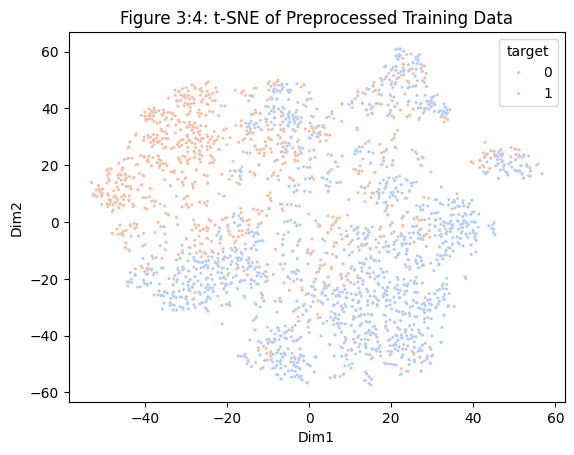

In [52]:
# Use t-SNE to visualize data in 2 dimensions
from sklearn.manifold import TSNE


X_train_preprocessed = preprocessor3.fit_transform(X_train)
X_test_preprocessed = preprocessor3.transform(X_test)

X_tsne = TSNE(n_components=2, random_state=13, perplexity=30).fit_transform(X_train_preprocessed)
tsne_df = pd.DataFrame(X_tsne, columns=['Dim1','Dim2'])
tsne_df['target'] = y_train.values

# now plot
sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2', hue='target', palette='coolwarm', s=5)
plt.title("Figure 3:4: t-SNE of Preprocessed Training Data")
plt.show()


In [53]:
# use cross validation to tune

kernels = ['linear', 'rbf']
Cs = [0.1, 1, 10]
gammas = ['scale', 0.1, 0.01]

svc_results = []

# test our tuning parameters
for test_kernel, test_C, test_gamma in product(kernels, Cs, gammas):

    pipe = ImbPipeline([
        ('preprocessor', preprocessor3),
        ('svm', SVC(kernel=test_kernel, C=test_C, gamma=test_gamma))
    ])

    # get accuracy and f1 score using 5-fold CV
    scores = cross_validate(
        pipe,
        X_train, y_train,
        cv=5,
        scoring={
            'accuracy': 'accuracy', 
            'recall_yes': make_scorer(recall_score, pos_label=1), 
            'f1_yes': make_scorer(f1_score, pos_label=1)
        },
        n_jobs=-1
    )

    svc_results.append({
        'kernel': test_kernel,
        'C': test_C,
        'gamma': test_gamma,
        'accuracy': scores['test_accuracy'].mean(),
        'recall_yes': scores['test_recall_yes'].mean(),
        'f1_mean': scores['test_f1_yes'].mean()
    })


In [54]:
# test our tuning parameters with SMOTE
for test_kernel, test_C, test_gamma in product(kernels, Cs, gammas):

    pipe = ImbPipeline([
        ('preprocessor', preprocessor3),
        ('smote', SMOTE(random_state=13)),
        ('svm', SVC(kernel=test_kernel, C=test_C, gamma=test_gamma))
    ])

    # get accuracy and f1 score using 5-fold CV
    scores = cross_validate(
        pipe,
        X_train, y_train,
        cv=5,
        scoring={
            'accuracy': 'accuracy', 
            'recall_yes': make_scorer(recall_score, pos_label=1), 
            'f1_yes': make_scorer(f1_score, pos_label=1)
        },
        n_jobs=-1
    )

    svc_results.append({
        'kernel': test_kernel + " w.SMOTE",
        'C': test_C,
        'gamma': test_gamma,
        'accuracy': scores['test_accuracy'].mean(),
        'recall_yes': scores['test_recall_yes'].mean(),
        'f1_mean': scores['test_f1_yes'].mean()
    })


print(pd.DataFrame(svc_results))

            kernel     C  gamma  accuracy  recall_yes   f1_mean
0           linear   0.1  scale  0.922722    0.842791  0.893860
1           linear   0.1    0.1  0.922722    0.842791  0.893860
2           linear   0.1   0.01  0.922722    0.842791  0.893860
3           linear   1.0  scale  0.920923    0.854884  0.893113
4           linear   1.0    0.1  0.920923    0.854884  0.893113
5           linear   1.0   0.01  0.920923    0.854884  0.893113
6           linear  10.0  scale  0.918046    0.853953  0.889561
7           linear  10.0    0.1  0.918046    0.853953  0.889561
8           linear  10.0   0.01  0.918046    0.853953  0.889561
9              rbf   0.1  scale  0.893964    0.738605  0.843277
10             rbf   0.1    0.1  0.887130    0.720000  0.831311
11             rbf   0.1   0.01  0.860889    0.642791  0.781032
12             rbf   1.0  scale  0.917328    0.820465  0.884524
13             rbf   1.0    0.1  0.918046    0.824186  0.885914
14             rbf   1.0   0.01  0.91625

In [55]:
# Linear SVM
linear_pipe = ImbPipeline([
    ('preprocessing', preprocessor3),
    ('classifier', SVC(kernel='linear', C=1, probability=True))
])
linear_pipe.fit(X_train, y_train)

eval_df = evaluate_model(linear_pipe, "SVMlinear")



SVMlinear

Confusion Matrix for SVMlinear
 [[414  13]
 [ 54 215]]

Classification Report for SVMlinear:
               precision    recall  f1-score   support

           0       0.88      0.97      0.93       427
           1       0.94      0.80      0.87       269

    accuracy                           0.90       696
   macro avg       0.91      0.88      0.90       696
weighted avg       0.91      0.90      0.90       696



In [56]:
# Mix-in Smote
linear_pipe_w_smote = ImbPipeline([
    ('preprocessing', preprocessor3),
    ('smote', SMOTE(random_state=13)),
    ('classifier', SVC(kernel='linear', C=1, probability=True))
])
linear_pipe_w_smote.fit(X_train, y_train)

eval_df = evaluate_model(linear_pipe_w_smote, "SVMlin w.SMOTE")



SVMlin w.SMOTE

Confusion Matrix for SVMlin w.SMOTE
 [[397  30]
 [ 45 224]]

Classification Report for SVMlin w.SMOTE:
               precision    recall  f1-score   support

           0       0.90      0.93      0.91       427
           1       0.88      0.83      0.86       269

    accuracy                           0.89       696
   macro avg       0.89      0.88      0.89       696
weighted avg       0.89      0.89      0.89       696



In [57]:

# Best RBF found
rbf_pipe = ImbPipeline([
    ('preprocessing', preprocessor3),
    ('classifier', SVC(kernel='rbf', C=10, gamma=0.01, probability=True))
])
rbf_pipe.fit(X_train, y_train)
eval_df = evaluate_model(rbf_pipe, "SVM_RBF")


SVM_RBF

Confusion Matrix for SVM_RBF
 [[411  16]
 [ 53 216]]

Classification Report for SVM_RBF:
               precision    recall  f1-score   support

           0       0.89      0.96      0.92       427
           1       0.93      0.80      0.86       269

    accuracy                           0.90       696
   macro avg       0.91      0.88      0.89       696
weighted avg       0.90      0.90      0.90       696



In [58]:
# Best RBF with SMOTE
rbf_pipe = ImbPipeline([
    ('preprocessing', preprocessor3),
    ('smote', SMOTE(random_state=13)),
    ('classifier', SVC(kernel='rbf', C=10, gamma=0.01, probability=True))
])
rbf_pipe.fit(X_train, y_train)
eval_df = evaluate_model(rbf_pipe, "SVM_RBF w.SMOTE")


SVM_RBF w.SMOTE

Confusion Matrix for SVM_RBF w.SMOTE
 [[406  21]
 [ 51 218]]

Classification Report for SVM_RBF w.SMOTE:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92       427
           1       0.91      0.81      0.86       269

    accuracy                           0.90       696
   macro avg       0.90      0.88      0.89       696
weighted avg       0.90      0.90      0.90       696



### 3.4 Neural Networds

In [59]:
# NN Using PyTorch
preprocessor_nn = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
            ('standardizer', StandardScaler())
        ]), numeric_cols)
    ], remainder='drop'
)


In [ ]:
# preprocess training and testing set
X_train_prep = preprocessor_nn.fit_transform(X_train)
X_test_prep  = preprocessor_nn.transform(X_test)


In [ ]:

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1,1)
X_test_tensor = torch.tensor(X_test_prep, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1,1)



In [ ]:
# Define Simple NN with flexible number of hidden layers
class LogisticRegression(nn.Module):
    def __init__(self, input_size, hidden_units):
        super(LogisticRegression, self).__init__()
        
        in_dim = input_size
        layers = []
        for h in hidden_units:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h

        layers.append(nn.Linear(in_dim, 1))

        self.network = nn.Sequential(*layers)


    def forward(self, x):
        return self.network(x)


In [ ]:
#  Helper to train using epochs in batches 

fold_history = []


In [ ]:

y_train_flat = y_train_tensor.numpy().flatten()


def evalWithCV(hidden_size, learning_rate=0.01, num_epochs=50, silent=True):
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=13)

    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_tensor, y_train_flat)):

        X_train_kfold = X_train_tensor[train_idx]
        y_train_kfold = y_train_tensor[train_idx]

        X_val = X_train_tensor[val_idx]
        y_val = y_train_tensor[val_idx]

        train_loader = DataLoader(TensorDataset(X_train_kfold, y_train_kfold),
                                batch_size=32, shuffle=True)
        
        val_loader   = DataLoader(TensorDataset(X_val, y_val),
                                batch_size=32, shuffle=False)
        input_size = X_train_tensor.shape[1]
        model = LogisticRegression(input_size, hidden_size)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)


        loss_hist = []
        acc_hist = []

        # train using epochs across batches 
        for epoch in range(num_epochs):
            model.train()
            train_loss = 0
            for x_batch, y_batch in train_loader:
                pred = model(x_batch)
                loss = criterion(pred, y_batch)
                loss.backward()
                optimizer.step()
                optimizer.zero_grad() 
                train_loss += loss.item() * x_batch.size(0)
            train_loss /= len(train_loader.dataset)
            loss_hist.append(train_loss)

            # validate model
            model.eval()
            val_loss = 0
            val_logits_list = []
            val_true_list = []

            with torch.no_grad():
                for x_val_batch, y_val_batch in val_loader:
                    logits = model(x_val_batch)
                    loss = criterion(logits, y_val_batch)
                    val_loss += loss.item() * x_val_batch.size(0)
                    val_logits_list.append(logits)
                    val_true_list.append(y_val_batch)

            val_loss /= len(val_loader.dataset)
            val_logits = torch.cat(val_logits_list, dim=0)
            val_probs  = torch.sigmoid(val_logits).numpy().flatten()
            val_true   = torch.cat(val_true_list, dim=0).numpy().flatten()
            val_pred = (val_probs >= 0.5).astype(int)
            val_acc = accuracy_score(val_true, val_pred)
            
            acc = val_acc
            prec, rec, f1, _ = precision_recall_fscore_support(val_true, val_pred, average='binary', zero_division=0)
            auc = roc_auc_score(val_true, val_probs)
            auprc = average_precision_score(val_true, val_probs)

            fold_metrics.append((val_loss, acc, prec, rec, f1, auc, auprc))
            acc_hist.append(f1)

            if (silent == False):
                print(f"E{epoch+1} / F:{fold+1} — Loss: {val_loss:.4g}, ACC: {acc:.4f}, PREC: {prec:.4f}, REC: {rec:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")

        fold_history.append({
            "train_loss": loss_hist,
            "val_acc": acc_hist
        }) 

    return fold_metrics

In [ ]:
# Helper for printing metrics
def printMetrics(mean_scores, std_scores):
    print(f"Loss: {mean_scores[0]:.4f} ± {std_scores[0]:.4f}")
    print(f"Accuracy: {mean_scores[1]:.4f} ± {std_scores[1]:.4f}")
    print(f"Precision: {mean_scores[2]:.4f} ± {std_scores[2]:.4f}")
    print(f"Recall: {mean_scores[3]:.4f} ± {std_scores[3]:.4f}")
    print(f"F1: {mean_scores[4]:.4f} ± {std_scores[4]:.4f}")
    print(f"AUC: {mean_scores[5]:.4f} ± {std_scores[5]:.4f}")
    print(f"AUPRC: {mean_scores[6]:.4f} ± {std_scores[6]:.4f}")


In [ ]:
# tain and evaluate NN model with 1 hidden layer and learning rate of 0.01
fold_metrics_nn0_raw = evalWithCV([32])


# print K-fold averages
fold_metrics_nn0 = np.array(fold_metrics_nn0_raw)

# print K-fold averages
mean_scores_0 = fold_metrics_nn0.mean(axis=0)
std_scores_0  = fold_metrics_nn0.std(axis=0)
printMetrics(mean_scores_0, std_scores_0)


Loss: 0.3741 ± 0.1437
Accuracy: 0.9099 ± 0.0170
Precision: 0.9091 ± 0.0384
Recall: 0.8538 ± 0.0300
F1: 0.8798 ± 0.0216
AUC: 0.9468 ± 0.0149
AUPRC: 0.9463 ± 0.0145


In [ ]:

fold_metrics_nn1_raw = evalWithCV([32], 1e-3, 50)

# print K-fold averages
fold_metrics_nn1 = np.array(fold_metrics_nn1_raw)

# print K-fold averages
mean_scores_1 = fold_metrics_nn1.mean(axis=0)
std_scores_1  = fold_metrics_nn1.std(axis=0)
printMetrics(mean_scores_1, std_scores_1)

Loss: 0.2229 ± 0.0527
Accuracy: 0.9199 ± 0.0197
Precision: 0.9365 ± 0.0256
Recall: 0.8507 ± 0.0463
F1: 0.8907 ± 0.0305
AUC: 0.9585 ± 0.0157
AUPRC: 0.9567 ± 0.0161


In [ ]:
# tain and evaluate NN model with 2 hidden layer
fold_metrics_nn2_raw = evalWithCV([32], 1e-4)

# print K-fold averages
fold_metrics_nn2 = np.array(fold_metrics_nn2_raw)

# print K-fold averages
mean_scores_2 = fold_metrics_nn2.mean(axis=0)
std_scores_2  = fold_metrics_nn2.std(axis=0)

printMetrics(mean_scores_2, std_scores_2)


Loss: 0.3421 ± 0.1226
Accuracy: 0.8693 ± 0.0705
Precision: 0.9153 ± 0.1144
Recall: 0.7183 ± 0.1760
F1: 0.7936 ± 0.1623
AUC: 0.9238 ± 0.0622
AUPRC: 0.9137 ± 0.0754


In [ ]:
# tain and evaluate NN model with 2 hidden layer
fold_metrics_nn3_raw = evalWithCV([64, 32])

# print K-fold averages
fold_metrics_nn3 = np.array(fold_metrics_nn3_raw)

# print K-fold averages
mean_scores_3 = fold_metrics_nn3.mean(axis=0)
std_scores_3  = fold_metrics_nn3.std(axis=0)

printMetrics(mean_scores_3, std_scores_3)

Loss: 0.4848 ± 0.1980
Accuracy: 0.9042 ± 0.0174
Precision: 0.8957 ± 0.0427
Recall: 0.8539 ± 0.0339
F1: 0.8731 ± 0.0217
AUC: 0.9440 ± 0.0158
AUPRC: 0.9428 ± 0.0150


In [ ]:
# tain and evaluate NN model with 2 hidden layer
fold_metrics_nn4_raw = evalWithCV([64, 32], 1e-3)

# print K-fold averages
fold_metrics_nn4 = np.array(fold_metrics_nn4_raw)

# print K-fold averages
mean_scores_4 = fold_metrics_nn4.mean(axis=0)
std_scores_4  = fold_metrics_nn4.std(axis=0)

printMetrics(mean_scores_4, std_scores_4)

Loss: 0.3244 ± 0.1393
Accuracy: 0.9121 ± 0.0209
Precision: 0.9122 ± 0.0402
Recall: 0.8567 ± 0.0413
F1: 0.8825 ± 0.0279
AUC: 0.9518 ± 0.0170
AUPRC: 0.9508 ± 0.0162


In [ ]:
# tain and evaluate NN model with 2 hidden layer
fold_metrics_nn5_raw = evalWithCV([64, 32], 1e-4)

# print K-fold averages
fold_metrics_nn5 = np.array(fold_metrics_nn5_raw)

# print K-fold averages
mean_scores_5 = fold_metrics_nn5.mean(axis=0)
std_scores_5  = fold_metrics_nn5.std(axis=0)

printMetrics(mean_scores_5, std_scores_5)

Loss: 0.2698 ± 0.1147
Accuracy: 0.9017 ± 0.0505
Precision: 0.9365 ± 0.0346
Recall: 0.8013 ± 0.1316
F1: 0.8554 ± 0.1060
AUC: 0.9468 ± 0.0302
AUPRC: 0.9439 ± 0.0360


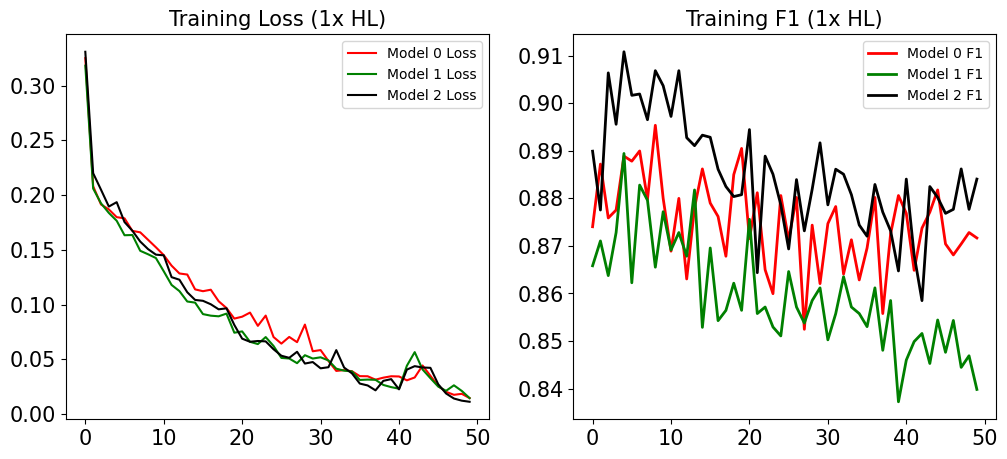

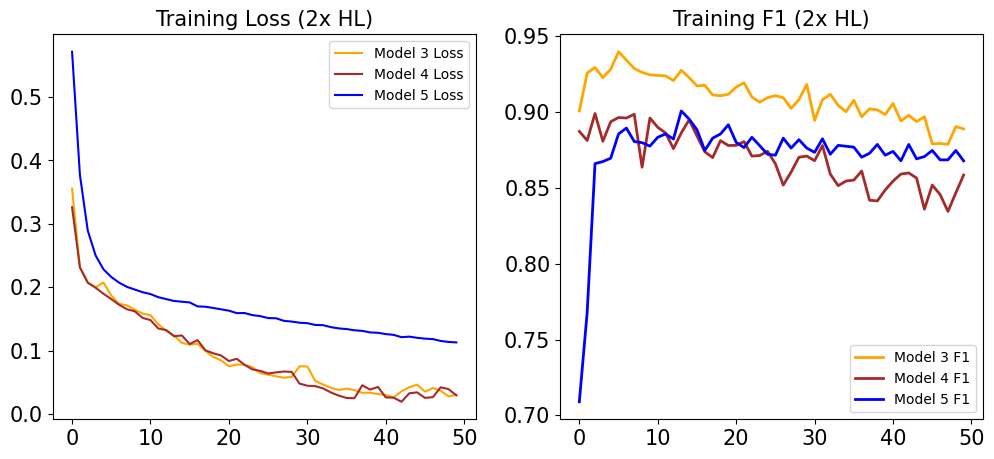

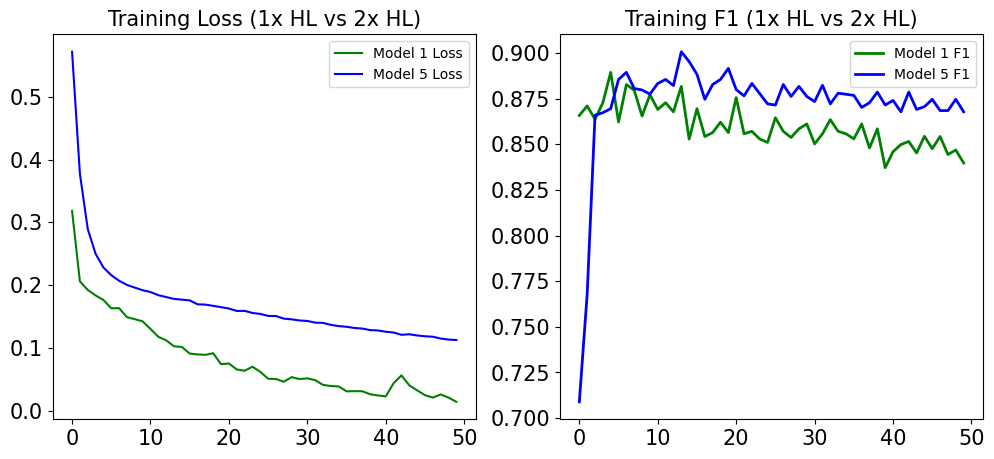

In [ ]:
# Plot evaluated models

fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(fold_history[0]['train_loss'], color="red", label="Model 0 Loss")
ax.plot(fold_history[1]['train_loss'], color="green", label="Model 1 Loss")
ax.plot(fold_history[2]['train_loss'], color="black", label="Model 2 Loss")
ax.set_title('Training Loss (1x HL)', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend()

ax = fig.add_subplot(1, 2, 2)
ax.plot(fold_history[0]['val_acc'], lw=2, color="red", label="Model 0 F1")
ax.plot(fold_history[1]['val_acc'], lw=2, color="green", label="Model 1 F1")
ax.plot(fold_history[2]['val_acc'], lw=2, color="black", label="Model 2 F1")
ax.set_title('Training F1 (1x HL)', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend()

plt.show()


fig = plt.figure(figsize=(12,5))

ax = fig.add_subplot(1, 2, 1)
ax.plot(fold_history[3]['train_loss'], color="orange", label="Model 3 Loss")
ax.plot(fold_history[4]['train_loss'], color="brown", label="Model 4 Loss")
ax.plot(fold_history[5]['train_loss'], color="blue", label="Model 5 Loss")
ax.set_title('Training Loss (2x HL)', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend()

ax = fig.add_subplot(1, 2, 2)
ax.plot(fold_history[3]['val_acc'], lw=2, color="orange", label="Model 3 F1")
ax.plot(fold_history[4]['val_acc'], lw=2, color="brown", label="Model 4 F1")
ax.plot(fold_history[5]['val_acc'], lw=2, color="blue", label="Model 5 F1")
ax.set_title('Training F1 (2x HL)', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend()

plt.show()

fig = plt.figure(figsize=(12,5))

ax = fig.add_subplot(1, 2, 1)
ax.plot(fold_history[1]['train_loss'], color="green", label="Model 1 Loss")
ax.plot(fold_history[5]['train_loss'], color="blue", label="Model 5 Loss")
ax.set_title('Training Loss (1x HL vs 2x HL)', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend()

ax = fig.add_subplot(1, 2, 2)
ax.plot(fold_history[1]['val_acc'], lw=2, color="green", label="Model 1 F1")
ax.plot(fold_history[5]['val_acc'], lw=2, color="blue", label="Model 5 F1")
ax.set_title('Training F1 (1x HL vs 2x HL)', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend()


In [ ]:
# Train NN model with full tensor dataset
seed = 13
np.random.seed(seed)
torch.manual_seed(seed)

nn_model1 = LogisticRegression(X_train_tensor.shape[1], [32])
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(nn_model1.parameters(), lr=1e-3, weight_decay=1e-4)


train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                                batch_size=32, shuffle=True)

# train using epochs across batches 
for epoch in range(50):

    for x_batch, y_batch in train_loader:
        pred = nn_model1(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad() 

In [ ]:
nn_model1.eval()
with torch.no_grad():
    logits = nn_model1(X_test_tensor)
    probs = torch.sigmoid(logits).cpu().numpy().flatten()
    preds = (probs >= 0.5).astype(int)

y_true = y_test_tensor.cpu().numpy().flatten()

print(f'Confusion Matrix for NN1\n', confusion_matrix(y_test, y_pred))
print(f"\nClassification Report for NN1:\n", classification_report(y_test, y_pred))

# eval_df = eval_df.drop(df[df["Model"] == "NN1"].index)
eval_df = append_eval("NN1", y_true, preds, probs)



Confusion Matrix for NN1
 [[383  43]
 [ 51 217]]

Classification Report for NN1:
               precision    recall  f1-score   support

           0       0.88      0.90      0.89       426
           1       0.83      0.81      0.82       268

    accuracy                           0.86       694
   macro avg       0.86      0.85      0.86       694
weighted avg       0.86      0.86      0.86       694



In [ ]:
print(X_train_tensor.shape)

torch.Size([2774, 92])


In [ ]:
# Train NN model with full tensor dataset
seed = 13
np.random.seed(seed)
torch.manual_seed(seed)

nn_model2 = LogisticRegression(X_train_tensor.shape[1], [64, 32])
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(nn_model2.parameters(), lr=1e-4, weight_decay=1e-4)

# train using epochs across batches 
for epoch in range(50):
    for x_batch, y_batch in train_loader:
        pred = nn_model2(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad() 

In [ ]:
nn_model5.eval()
with torch.no_grad():
    logits = nn_model5(X_test_tensor)
    probs = torch.sigmoid(logits).cpu().numpy().flatten()
    preds = (probs >= 0.5).astype(int)

y_true = y_test_tensor.cpu().numpy().flatten()

print(f'Confusion Matrix for NN1\n', confusion_matrix(y_test, y_pred))
print(f"\nClassification Report for NN1:\n", classification_report(y_test, y_pred))

eval_df = append_eval("NN5", y_true, preds, probs)



Confusion Matrix for NN1
 [[383  43]
 [ 51 217]]

Classification Report for NN1:
               precision    recall  f1-score   support

           0       0.88      0.90      0.89       426
           1       0.83      0.81      0.82       268

    accuracy                           0.86       694
   macro avg       0.86      0.85      0.86       694
weighted avg       0.86      0.86      0.86       694



In [ ]:

print(eval_df)


              Model  Accuracy      Prec    Recall        F1       AUC     AUPRC
0     Decision Tree  0.877522  0.892704  0.776119  0.830339  0.878210  0.858240
1               RF0  0.902017  0.938596  0.798507  0.862903  0.940776  0.940898
2               RF1  0.903458  0.938865  0.802239  0.865191  0.943531  0.942258
3               XG0  0.914986  0.940928  0.832090  0.883168  0.941656  0.943156
4               XG1  0.909222  0.936170  0.820896  0.874751  0.943066  0.943740
5               XG2  0.909222  0.936170  0.820896  0.874751  0.943066  0.943740
6              SVM0  0.904899  0.942982  0.802239  0.866935  0.941656  0.941852
7         SVMlinear  0.907781  0.943478  0.809701  0.871486  0.935661  0.938823
8    SVMlin w.SMOTE  0.891931  0.887550  0.824627  0.854932  0.932240  0.935464
9           SVM_RBF  0.900576  0.919831  0.813433  0.863366  0.938122  0.939636
10  SVM_RBF w.SMOTE  0.894813  0.904564  0.813433  0.856582  0.938126  0.938646
11              NN1  0.906340  0.907631 

SHAP values shape: (50, 92)


<positron-console-cell-953>:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
/Users/marcocastro/Documents/SPS/Data622/myvenv/lib/python3.13/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


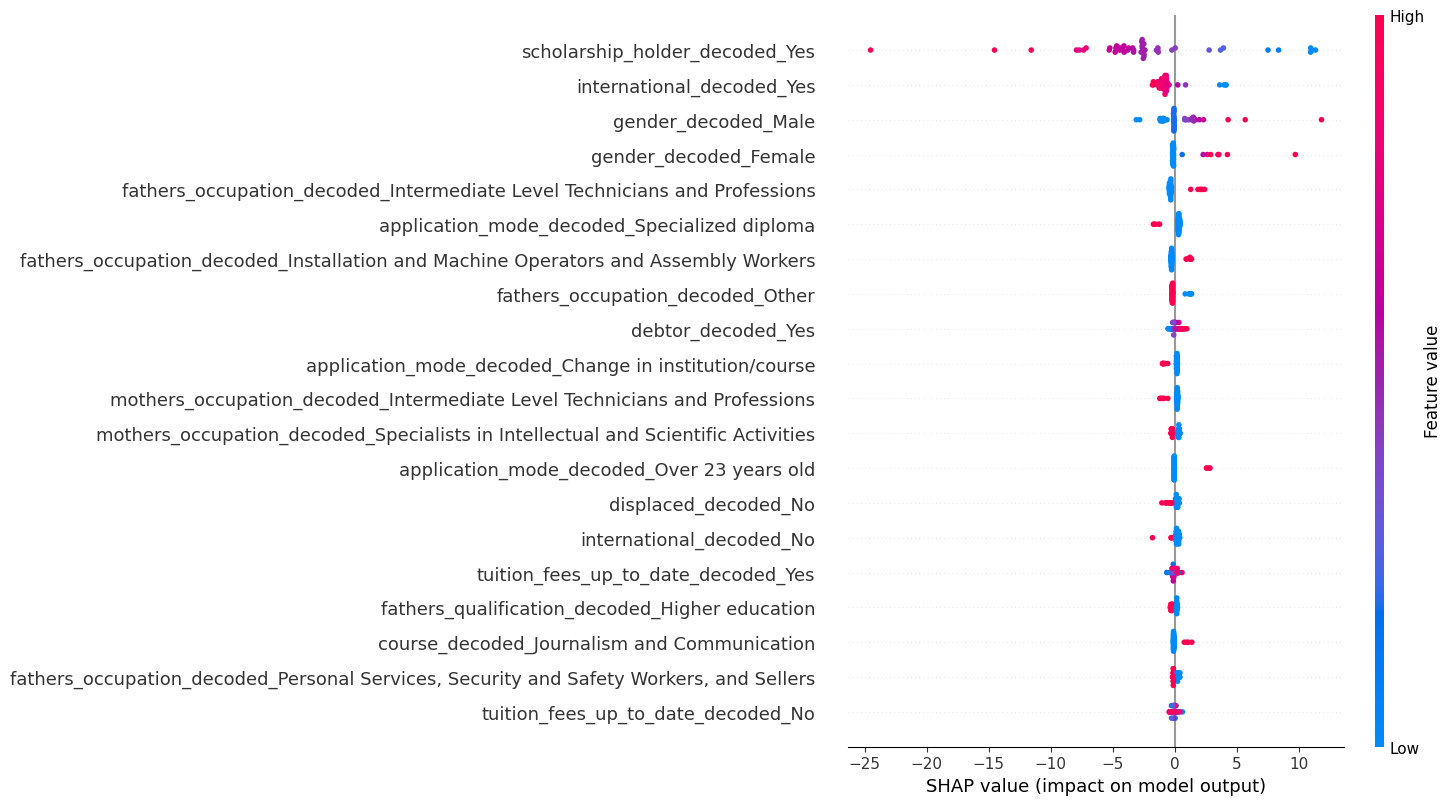

In [ ]:
# Use SHAP to summarize feature importance in NN model

import shap

num_features = numeric_cols
ohe = preprocessor2.named_transformers_['cat'].named_steps['encoder']
cat_features = ohe.get_feature_names_out(categorical_cols)
feature_names = np.concatenate([num_features, cat_features])

background = X_train_tensor[:100]
X_eval = X_test_tensor[:50] 

explainer = shap.DeepExplainer(nn_model1, background)
shap_values = explainer.shap_values(X_eval)

if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
    shap_vals = shap_values.squeeze(-1)
else:
    shap_vals = shap_values

print("SHAP values shape:", shap_vals.shape)  #


shap.summary_plot(
    shap_vals,
    X_eval.numpy(),
    feature_names=feature_names,
    plot_type="dot"
)


In [ ]:
print(X_train_tensor.shape)

torch.Size([2427, 92])
